In [ ]:
!pip install -U scikit-learn==1.6.0 imbalanced-learn==0.12.3


import numpy as np
import pandas as pd
from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline as SkPipeline
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, confusion_matrix, RocCurveDisplay)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier

from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE, ADASYN, KMeansSMOTE
from imblearn.combine import SMOTETomek, SMOTEENN
from imblearn.under_sampling import NearMiss, InstanceHardnessThreshold
from imblearn.base import SamplerMixin
from sklearn.base import BaseEstimator
from sklearn.neighbors import NearestNeighbors
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 200)


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.1/13.1 MB 127.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 258.3/258.3 kB 23.9 MB/s eta 0:00:00
  Attempting uninstall: scikit-learn
    Found existing installation: scikit-learn 1.6.1
    Uninstalling scikit-learn-1.6.1:
      Successfully uninstalled scikit-learn-1.6.1
  Attempting uninstall: imbalanced-learn
    Found existing installation: imbalanced-learn 0.14.0
    Uninstalling imbalanced-learn-0.14.0:
      Successfully uninstalled imbalanced-learn-0.14.0


In [ ]:
from google.colab import drive
drive.mount('/content/drive')
DATA_PATH = "/content/drive/MyDrive/CP2 dataset.csv"


Mounted at /content/drive


In [ ]:
df = pd.read_csv(DATA_PATH)
print(df.shape)
df.head()

(7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [ ]:
# Drop ID
if "customerID" in df.columns:
    df = df.drop(columns=["customerID"])

# Coerce TotalCharges to numeric if present
if "TotalCharges" in df.columns:
    df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

# Strip whitespace in text columns (just in case)
for c in df.select_dtypes(include=["object"]).columns:
    df[c] = df[c].astype(str).str.strip()

# Drop rows with NA after coercions
df = df.dropna().reset_index(drop=True)

# Target
target_col = "Churn"
assert target_col in df.columns, f"Target column '{target_col}' not found."

# Encode target to 0/1 (Yes -> 1, No -> 0)
y = (df[target_col].astype(str).str.lower() == "yes").astype(int)
X = df.drop(columns=[target_col])

# Identify numeric / categorical
numeric_features = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = X.select_dtypes(include=["object", "bool"]).columns.tolist()

print("Numeric features:", numeric_features)
print("Categorical features:", categorical_features)

# Train/test split (stratified)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

# Preprocessor
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), categorical_features),
    ],
    remainder="drop",
)


Numeric features: ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']
Categorical features: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


===== BASELINE: Logistic Regression (NO SAMPLING) ====
              precision    recall  f1-score   support

    No Churn       0.85      0.89      0.87      1291
       Churn       0.66      0.57      0.61       467

    accuracy                           0.81      1758
   macro avg       0.75      0.73      0.74      1758
weighted avg       0.80      0.81      0.80      1758

Baseline F1 (Churn): 0.6119
Baseline ROC_AUC   : 0.8402


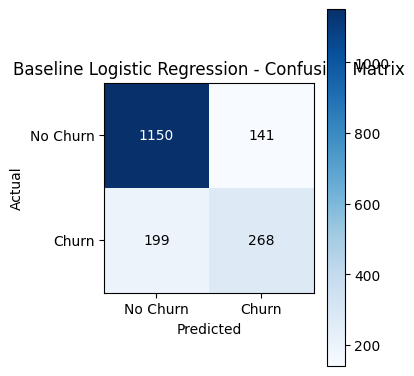

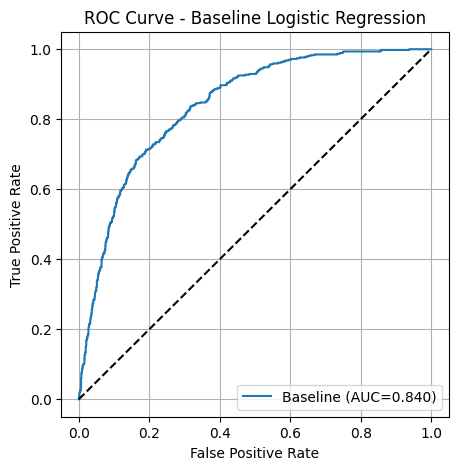

/usr/local/lib/python3.12/dist-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/_tags.py:354: FutureWarning: The SMOTE or classes from which it inherits use `_get_tags` and `_more_tags`. Please define the `__sklearn_tags__` method, or inherit from `sklearn.base.BaseEstimator` and/or other appropriate mixins such as `sklearn.base.TransformerMixin`, `sklearn.base.ClassifierMixin`, `sklearn.base.RegressorMixin`, and `sklearn.base.OutlierMixin`. From scikit-learn 1.7, not defining `__sklearn_tags__` will raise an error.
  warnings.warn(



===== SMOTE + Logistic Regression ====
              precision    recall  f1-score   support

    No Churn       0.91      0.72      0.80      1291
       Churn       0.50      0.80      0.62       467

    accuracy                           0.74      1758
   macro avg       0.71      0.76      0.71      1758
weighted avg       0.80      0.74      0.75      1758

SMOTE F1 (Churn): 0.6169
SMOTE ROC_AUC   : 0.8397


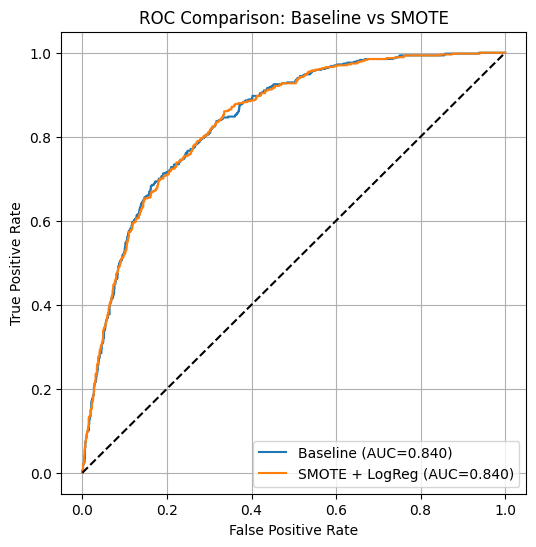

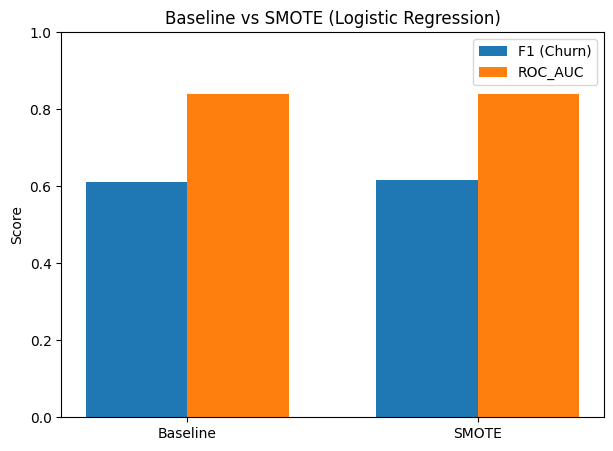

In [ ]:
# ========================================
# BASELINE PIPELINE
# ========================================
from sklearn.metrics import classification_report, roc_curve

baseline_pipe = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("clf", LogisticRegression(max_iter=1000))
])

baseline_pipe.fit(X_train, y_train)

y_pred_base = baseline_pipe.predict(X_test)
y_prob_base = baseline_pipe.predict_proba(X_test)[:, 1]

print("===== BASELINE: Logistic Regression (NO SAMPLING) ====")
print(classification_report(y_test, y_pred_base, target_names=["No Churn", "Churn"]))

baseline_f1 = f1_score(y_test, y_pred_base)
baseline_auc = roc_auc_score(y_test, y_prob_base)
print(f"Baseline F1 (Churn): {baseline_f1:.4f}")
print(f"Baseline ROC_AUC   : {baseline_auc:.4f}")

# Baseline Confusion Matrix
cm_base = confusion_matrix(y_test, y_pred_base)

plt.figure(figsize=(4,4))
plt.imshow(cm_base, interpolation="nearest", cmap="Blues")
plt.title("Baseline Logistic Regression - Confusion Matrix")
plt.colorbar()

tick_marks = np.arange(2)
plt.xticks(tick_marks, ["No Churn", "Churn"])
plt.yticks(tick_marks, ["No Churn", "Churn"])

thresh = cm_base.max() / 2
for i in range(cm_base.shape[0]):
    for j in range(cm_base.shape[1]):
        plt.text(j, i, format(cm_base[i, j], "d"),
                 ha="center", va="center",
                 color="white" if cm_base[i, j] > thresh else "black")

plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.tight_layout()
plt.show()

# Baseline ROC Curve
fpr_base, tpr_base, _ = roc_curve(y_test, y_prob_base)

plt.figure(figsize=(5,5))
plt.plot(fpr_base, tpr_base, label=f"Baseline (AUC={baseline_auc:.3f})")
plt.plot([0, 1], [0, 1], "k--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Baseline Logistic Regression")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

# SMOTE + Logistic Regression
from imblearn.pipeline import Pipeline as ImbPipeline

smote_pipe = ImbPipeline(steps=[
    ("preprocessor", preprocessor),
    ("smote", SMOTE(random_state=42)),
    ("clf", LogisticRegression(max_iter=1000))
])

smote_pipe.fit(X_train, y_train)

y_pred_smote = smote_pipe.predict(X_test)
y_prob_smote = smote_pipe.predict_proba(X_test)[:, 1]

print("\n===== SMOTE + Logistic Regression ====")
print(classification_report(y_test, y_pred_smote, target_names=["No Churn", "Churn"]))

smote_f1 = f1_score(y_test, y_pred_smote)
smote_auc = roc_auc_score(y_test, y_prob_smote)
print(f"SMOTE F1 (Churn): {smote_f1:.4f}")
print(f"SMOTE ROC_AUC   : {smote_auc:.4f}")

# ROC Curve Comparison: Baseline vs SMOTE
fpr_smote, tpr_smote, _ = roc_curve(y_test, y_prob_smote)

plt.figure(figsize=(6,6))
plt.plot(fpr_base, tpr_base, label=f"Baseline (AUC={baseline_auc:.3f})")
plt.plot(fpr_smote, tpr_smote, label=f"SMOTE + LogReg (AUC={smote_auc:.3f})")
plt.plot([0,1],[0,1],"k--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Comparison: Baseline vs SMOTE")
plt.legend()
plt.grid(True)
plt.show()


# Comparison Chart
metrics_df = pd.DataFrame({
    "Model": ["Baseline", "SMOTE"],
    "F1_churn": [baseline_f1, smote_f1],
    "ROC_AUC": [baseline_auc, smote_auc]
})

x = np.arange(len(metrics_df))
width = 0.35

plt.figure(figsize=(7,5))
plt.bar(x - width/2, metrics_df["F1_churn"], width, label="F1 (Churn)")
plt.bar(x + width/2, metrics_df["ROC_AUC"], width, label="ROC_AUC")

plt.xticks(x, metrics_df["Model"])
plt.ylim(0,1)
plt.ylabel("Score")
plt.title("Baseline vs SMOTE (Logistic Regression)")
plt.legend()
plt.show()

In [ ]:
from sklearn.metrics import f1_score, roc_auc_score, roc_curve, classification_report

# Baseline model evaluation
baseline_models = {
    "LogReg": LogisticRegression(max_iter=1000),
    "SVM": SVC(probability=True, random_state=42),
    "RF": RandomForestClassifier(n_estimators=200, random_state=42),
    "DT": DecisionTreeClassifier(random_state=42),
}

baseline_results = {}  # store metrics + ROC points for each model

for name, model in baseline_models.items():
    pipe = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("clf", model),
    ])
    pipe.fit(X_train, y_train)

    y_pred = pipe.predict(X_test)
    y_prob = pipe.predict_proba(X_test)[:, 1]

    f1 = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_prob)
    fpr, tpr, _ = roc_curve(y_test, y_prob)

    print(f"\n===== BASELINE: {name} (NO SAMPLING) ====")
    print(classification_report(y_test, y_pred, target_names=["No Churn", "Churn"]))
    print(f"{name} Baseline F1 (Churn): {f1:.4f}")
    print(f"{name} Baseline ROC_AUC   : {auc:.4f}")

    baseline_results[name] = {
        "model": model,
        "pipe": pipe,
        "f1": f1,
        "auc": auc,
        "fpr": fpr,
        "tpr": tpr,
    }


===== BASELINE: LogReg (NO SAMPLING) ====
              precision    recall  f1-score   support

    No Churn       0.85      0.89      0.87      1291
       Churn       0.66      0.57      0.61       467

    accuracy                           0.81      1758
   macro avg       0.75      0.73      0.74      1758
weighted avg       0.80      0.81      0.80      1758

LogReg Baseline F1 (Churn): 0.6119
LogReg Baseline ROC_AUC   : 0.8402

===== BASELINE: SVM (NO SAMPLING) ====
              precision    recall  f1-score   support

    No Churn       0.83      0.91      0.87      1291
       Churn       0.66      0.49      0.56       467

    accuracy                           0.80      1758
   macro avg       0.74      0.70      0.71      1758
weighted avg       0.79      0.80      0.79      1758

SVM Baseline F1 (Churn): 0.5620
SVM Baseline ROC_AUC   : 0.7955

===== BASELINE: RF (NO SAMPLING) ====
              precision    recall  f1-score   support

    No Churn       0.82      0.89  


===== BASELINE: LogReg (NO SAMPLING) =====
              precision    recall  f1-score   support

    No Churn       0.85      0.89      0.87      1291
       Churn       0.66      0.57      0.61       467

    accuracy                           0.81      1758
   macro avg       0.75      0.73      0.74      1758
weighted avg       0.80      0.81      0.80      1758

LogReg Baseline F1 (Churn): 0.6119
LogReg Baseline ROC_AUC   : 0.8402


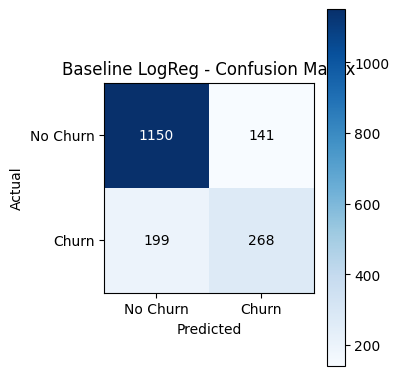

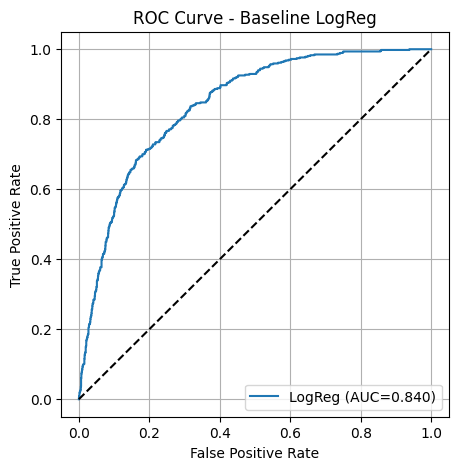


===== BASELINE: DecisionTree (NO SAMPLING) =====
              precision    recall  f1-score   support

    No Churn       0.81      0.81      0.81      1291
       Churn       0.48      0.48      0.48       467

    accuracy                           0.72      1758
   macro avg       0.65      0.65      0.65      1758
weighted avg       0.72      0.72      0.72      1758

DecisionTree Baseline F1 (Churn): 0.4813
DecisionTree Baseline ROC_AUC   : 0.6464


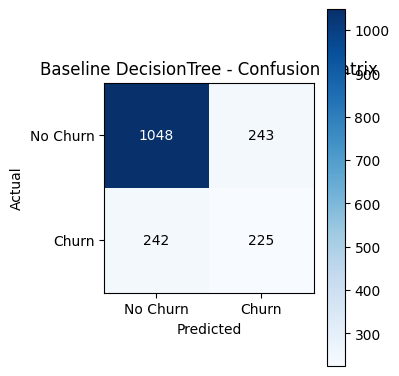

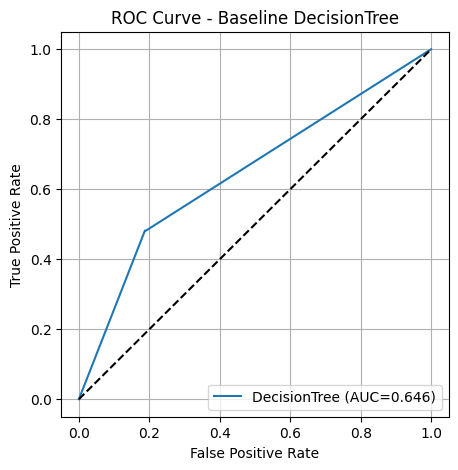


===== BASELINE: RandomForest (NO SAMPLING) =====
              precision    recall  f1-score   support

    No Churn       0.82      0.89      0.85      1291
       Churn       0.61      0.47      0.53       467

    accuracy                           0.78      1758
   macro avg       0.71      0.68      0.69      1758
weighted avg       0.77      0.78      0.77      1758

RandomForest Baseline F1 (Churn): 0.5290
RandomForest Baseline ROC_AUC   : 0.8136


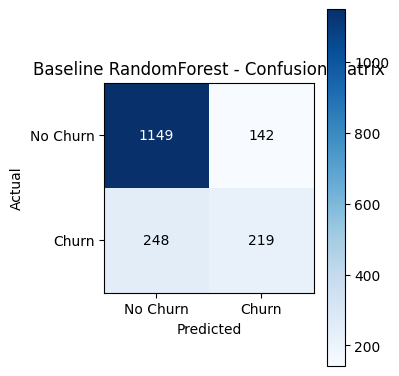

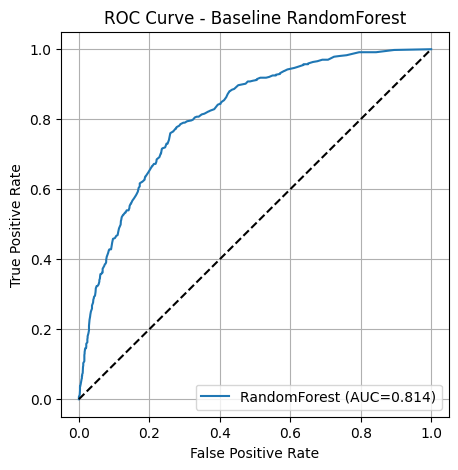


===== BASELINE: SVM (NO SAMPLING) =====
              precision    recall  f1-score   support

    No Churn       0.83      0.91      0.87      1291
       Churn       0.66      0.49      0.56       467

    accuracy                           0.80      1758
   macro avg       0.74      0.70      0.71      1758
weighted avg       0.79      0.80      0.79      1758

SVM Baseline F1 (Churn): 0.5620
SVM Baseline ROC_AUC   : 0.7955


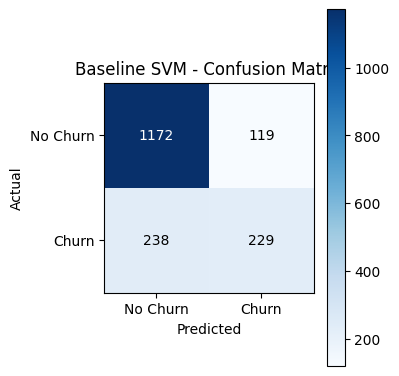

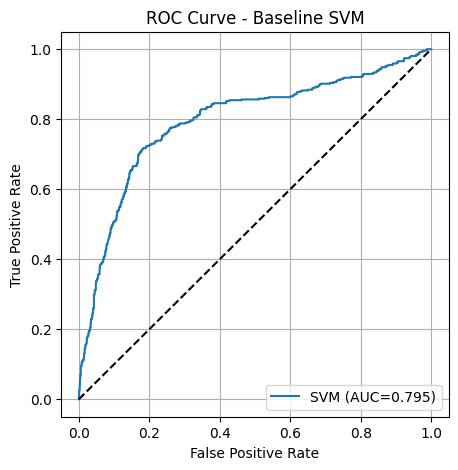

In [ ]:
# ========================================
# MULTI-MODEL BASELINES (NO SAMPLING)
# ========================================

baseline_results = {}  # this is what compare_with_baseline will use

def build_baseline(model_name, clf):
    """
    Train a baseline model (no sampling), evaluate it,
    plot confusion matrix + ROC, and store into baseline_results.
    """
    print(f"\n===== BASELINE: {model_name} (NO SAMPLING) =====")

    pipe = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("clf", clf)
    ])

    pipe.fit(X_train, y_train)

    y_pred = pipe.predict(X_test)
    y_prob = pipe.predict_proba(X_test)[:, 1]

    print(classification_report(y_test, y_pred, target_names=["No Churn", "Churn"]))

    f1 = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_prob)
    print(f"{model_name} Baseline F1 (Churn): {f1:.4f}")
    print(f"{model_name} Baseline ROC_AUC   : {auc:.4f}")

    # Confusion matrix
    cm = confusion_matrix(y_test, y_pred)

    plt.figure(figsize=(4,4))
    plt.imshow(cm, interpolation="nearest", cmap="Blues")
    plt.title(f"Baseline {model_name} - Confusion Matrix")
    plt.colorbar()

    tick_marks = np.arange(2)
    plt.xticks(tick_marks, ["No Churn", "Churn"])
    plt.yticks(tick_marks, ["No Churn", "Churn"])

    thresh = cm.max() / 2
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(
                j, i, format(cm[i, j], "d"),
                ha="center", va="center",
                color="white" if cm[i, j] > thresh else "black"
            )

    plt.ylabel("Actual")
    plt.xlabel("Predicted")
    plt.tight_layout()
    plt.show()

    # ROC curve
    fpr, tpr, _ = roc_curve(y_test, y_prob)

    plt.figure(figsize=(5,5))
    plt.plot(fpr, tpr, label=f"{model_name} (AUC={auc:.3f})")
    plt.plot([0, 1], [0, 1], "k--")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"ROC Curve - Baseline {model_name}")
    plt.legend(loc="lower right")
    plt.grid(True)
    plt.show()

    # Store in baseline_results for compare_with_baseline()
    baseline_results[model_name] = {
        "model": clf,   # the classifier instance (with its current params)
        "f1": f1,
        "auc": auc,
        "fpr": fpr,
        "tpr": tpr,
    }


# ===== Build all four baselines =====
build_baseline(
    model_name="LogReg",
    clf=LogisticRegression(max_iter=1000)
)

build_baseline(
    model_name="DecisionTree",
    clf=DecisionTreeClassifier(random_state=42)
)

build_baseline(
    model_name="RandomForest",
    clf=RandomForestClassifier(
        n_estimators=200,
        random_state=42
    )
)

build_baseline(
    model_name="SVM",
    clf=SVC(
        probability=True,
        kernel="rbf",
        random_state=42
    )
)


In [ ]:

def compare_with_baseline(sampler_name, sampler, model_name):
    """
    Compare a sampler + chosen model with that model's own baseline.

    sampler_name: string label for the sampler (e.g., "SMOTE")
    sampler: an instance of a sampler (SMOTE, ADASYN, etc.)
    model_name: key from baseline_results, e.g. "LogReg", "SVM"
    """
    base_info = baseline_results[model_name]
    base_model = base_info["model"]
    base_f1 = base_info["f1"]
    base_auc = base_info["auc"]
    base_fpr = base_info["fpr"]
    base_tpr = base_info["tpr"]

    pipe = ImbPipeline(steps=[
        ("preprocessor", preprocessor),
        ("sampler", sampler),
        ("clf", base_model.__class__(**base_model.get_params())),
    ])

    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)
    y_prob = pipe.predict_proba(X_test)[:, 1]

    f1 = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_prob)

    print(f"\n===== {sampler_name} + {model_name} =====")
    print(classification_report(y_test, y_pred, target_names=["No Churn", "Churn"]))
    print(f"{sampler_name} + {model_name} F1 (Churn): {f1:.4f}")
    print(f"{sampler_name} + {model_name} ROC_AUC   : {auc:.4f}")

    # Confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(4,4))
    plt.imshow(cm, interpolation="nearest", cmap="Blues")
    plt.title(f"{sampler_name} + {model_name} - Confusion Matrix")
    plt.colorbar()
    tick_marks = np.arange(2)
    plt.xticks(tick_marks, ["No Churn", "Churn"])
    plt.yticks(tick_marks, ["No Churn", "Churn"])

    thresh = cm.max() / 2
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(
                j, i, format(cm[i, j], "d"),
                ha="center", va="center",
                color="white" if cm[i, j] > thresh else "black"
            )

    plt.ylabel("Actual")
    plt.xlabel("Predicted")
    plt.tight_layout()
    plt.show()

    # ROC curve vs that model's baseline
    fpr_s, tpr_s, _ = roc_curve(y_test, y_prob)

    plt.figure(figsize=(5,5))
    plt.plot(base_fpr, base_tpr, label=f"Baseline {model_name} (AUC={base_auc:.3f})")
    plt.plot(fpr_s, tpr_s, label=f"{sampler_name} + {model_name} (AUC={auc:.3f})")
    plt.plot([0,1],[0,1],"k--")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"ROC: {sampler_name} + {model_name} vs Baseline {model_name}")
    plt.legend(loc="lower right")
    plt.grid(True)
    plt.show()

    # Bar chart (F1 & AUC)
    labels = [f"Baseline {model_name}", f"{sampler_name} + {model_name}"]
    f1_vals = [base_f1, f1]
    auc_vals = [base_auc, auc]
    x = np.arange(len(labels))
    width = 0.35

    plt.figure(figsize=(6,4))
    plt.bar(x - width/2, f1_vals, width, label="F1 (Churn)")
    plt.bar(x + width/2, auc_vals, width, label="ROC_AUC")
    plt.xticks(x, labels, rotation=10)
    plt.ylim(0,1)
    plt.ylabel("Score")
    plt.title(f"Baseline {model_name} vs {sampler_name} + {model_name}")
    plt.legend()
    plt.tight_layout()
    plt.show()

    return {
        "sampler": sampler_name,
        "model": model_name,
        "f1": f1,
        "auc": auc,
    }


/usr/local/lib/python3.12/dist-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/_tags.py:354: FutureWarning: The SMOTE or classes from which it inherits use `_get_tags` and `_more_tags`. Please define the `__sklearn_tags__` method, or inherit from `sklearn.base.BaseEstimator` and/or other appropriate mixins such as `sklearn.base.TransformerMixin`, `sklearn.base.ClassifierMixin`, `sklearn.base.RegressorMixin`, and `sklearn.base.OutlierMixin`. From scikit-learn 1.7, not defining `__sklearn_tags__` will raise an error.
  warnings.warn(



===== SMOTE + LogReg =====
              precision    recall  f1-score   support

    No Churn       0.91      0.72      0.80      1291
       Churn       0.50      0.80      0.62       467

    accuracy                           0.74      1758
   macro avg       0.71      0.76      0.71      1758
weighted avg       0.80      0.74      0.75      1758

SMOTE + LogReg F1 (Churn): 0.6169
SMOTE + LogReg ROC_AUC   : 0.8397


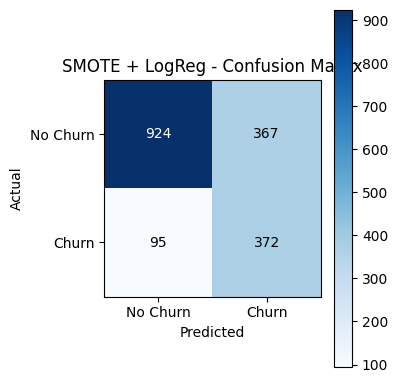

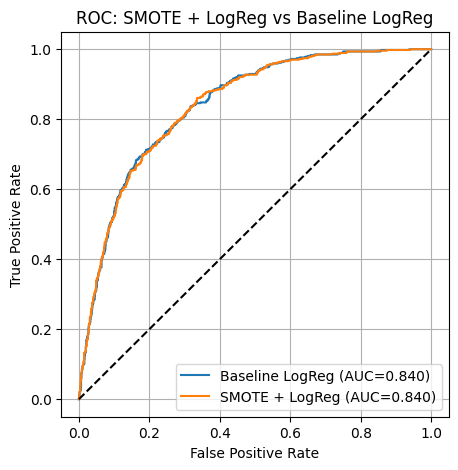

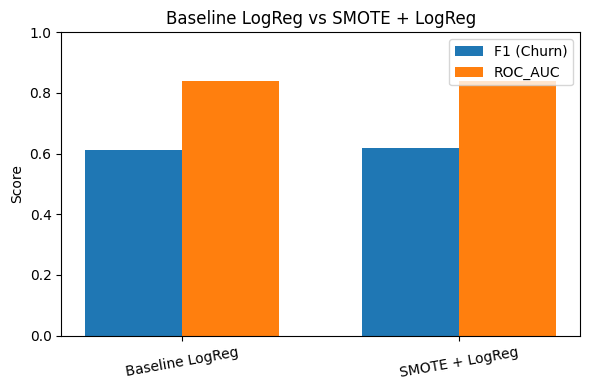

/usr/local/lib/python3.12/dist-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/_tags.py:354: FutureWarning: The SMOTE or classes from which it inherits use `_get_tags` and `_more_tags`. Please define the `__sklearn_tags__` method, or inherit from `sklearn.base.BaseEstimator` and/or other appropriate mixins such as `sklearn.base.TransformerMixin`, `sklearn.base.ClassifierMixin`, `sklearn.base.RegressorMixin`, and `sklearn.base.OutlierMixin`. From scikit-learn 1.7, not defining `__sklearn_tags__` will raise an error.
  warnings.warn(



===== SMOTE + DecisionTree =====
              precision    recall  f1-score   support

    No Churn       0.83      0.79      0.81      1291
       Churn       0.49      0.57      0.52       467

    accuracy                           0.73      1758
   macro avg       0.66      0.68      0.67      1758
weighted avg       0.74      0.73      0.73      1758

SMOTE + DecisionTree F1 (Churn): 0.5249
SMOTE + DecisionTree ROC_AUC   : 0.6760


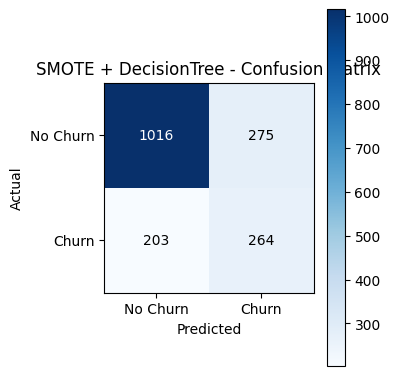

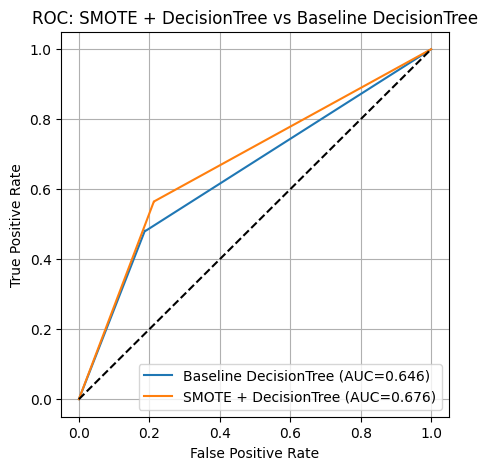

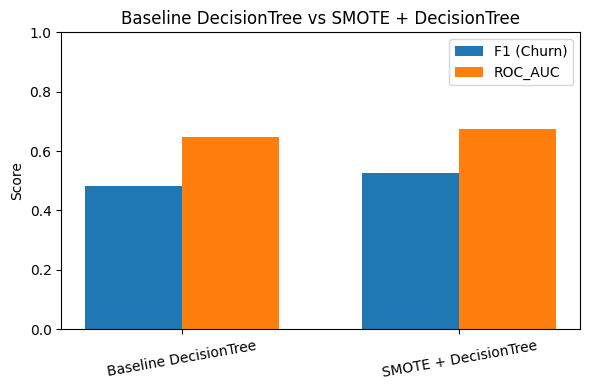

/usr/local/lib/python3.12/dist-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/_tags.py:354: FutureWarning: The SMOTE or classes from which it inherits use `_get_tags` and `_more_tags`. Please define the `__sklearn_tags__` method, or inherit from `sklearn.base.BaseEstimator` and/or other appropriate mixins such as `sklearn.base.TransformerMixin`, `sklearn.base.ClassifierMixin`, `sklearn.base.RegressorMixin`, and `sklearn.base.OutlierMixin`. From scikit-learn 1.7, not defining `__sklearn_tags__` will raise an error.
  warnings.warn(



===== SMOTE + RandomForest =====
              precision    recall  f1-score   support

    No Churn       0.83      0.85      0.84      1291
       Churn       0.56      0.53      0.54       467

    accuracy                           0.76      1758
   macro avg       0.70      0.69      0.69      1758
weighted avg       0.76      0.76      0.76      1758

SMOTE + RandomForest F1 (Churn): 0.5449
SMOTE + RandomForest ROC_AUC   : 0.8108


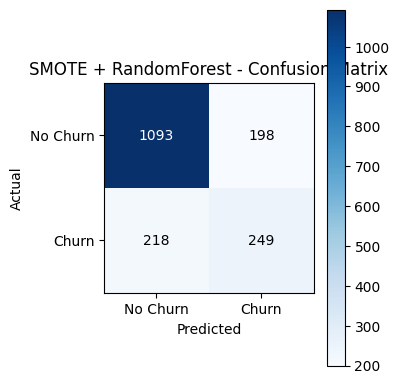

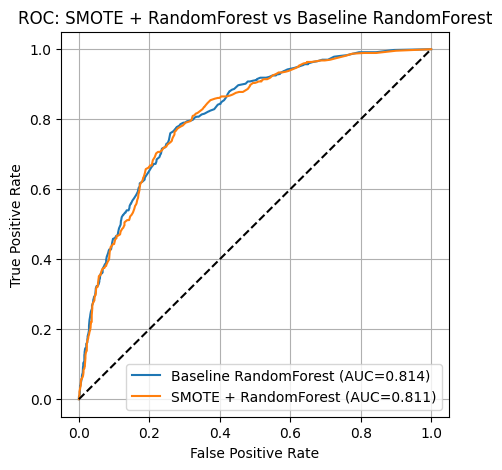

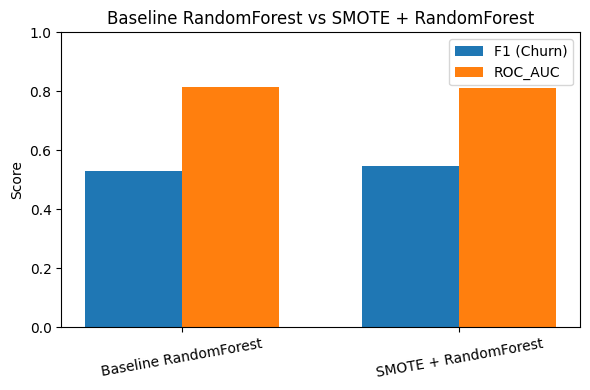

/usr/local/lib/python3.12/dist-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/_tags.py:354: FutureWarning: The SMOTE or classes from which it inherits use `_get_tags` and `_more_tags`. Please define the `__sklearn_tags__` method, or inherit from `sklearn.base.BaseEstimator` and/or other appropriate mixins such as `sklearn.base.TransformerMixin`, `sklearn.base.ClassifierMixin`, `sklearn.base.RegressorMixin`, and `sklearn.base.OutlierMixin`. From scikit-learn 1.7, not defining `__sklearn_tags__` will raise an error.
  warnings.warn(



===== SMOTE + SVM =====
              precision    recall  f1-score   support

    No Churn       0.89      0.76      0.82      1291
       Churn       0.53      0.75      0.62       467

    accuracy                           0.75      1758
   macro avg       0.71      0.75      0.72      1758
weighted avg       0.80      0.75      0.77      1758

SMOTE + SVM F1 (Churn): 0.6182
SMOTE + SVM ROC_AUC   : 0.8148


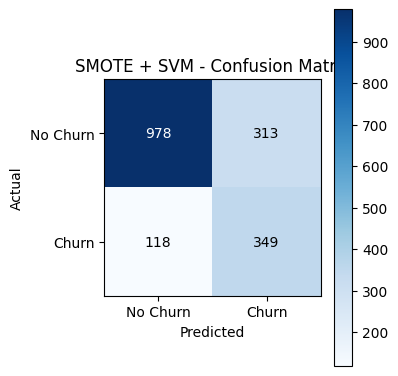

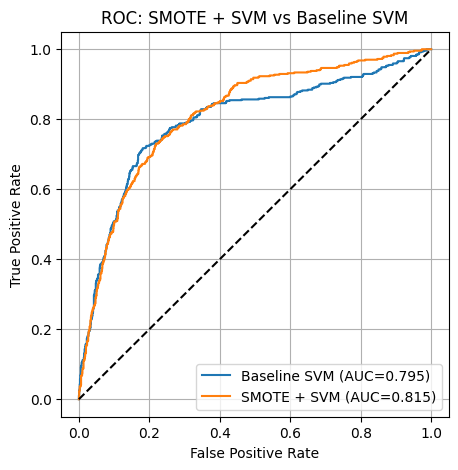

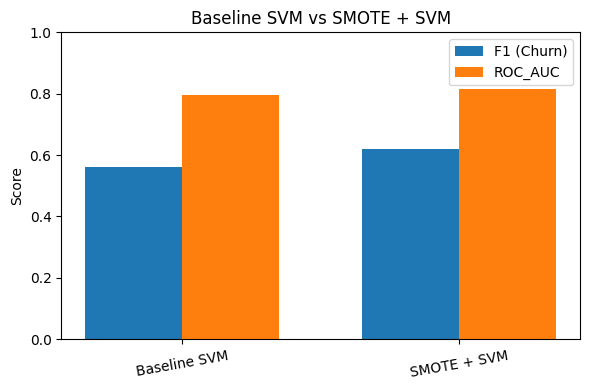

In [ ]:
# ===== SMOTE + 4 Models =====
smote_logreg_results = compare_with_baseline(
    sampler_name="SMOTE",
    sampler=SMOTE(random_state=42),
    model_name="LogReg"
)

smote_dt_results = compare_with_baseline(
    sampler_name="SMOTE",
    sampler=SMOTE(random_state=42),
    model_name="DecisionTree"
)

smote_rf_results = compare_with_baseline(
    sampler_name="SMOTE",
    sampler=SMOTE(random_state=42),
    model_name="RandomForest"
)

smote_svm_results = compare_with_baseline(
    sampler_name="SMOTE",
    sampler=SMOTE(random_state=42),
    model_name="SVM"
)


/usr/local/lib/python3.12/dist-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/_tags.py:354: FutureWarning: The ADASYN or classes from which it inherits use `_get_tags` and `_more_tags`. Please define the `__sklearn_tags__` method, or inherit from `sklearn.base.BaseEstimator` and/or other appropriate mixins such as `sklearn.base.TransformerMixin`, `sklearn.base.ClassifierMixin`, `sklearn.base.RegressorMixin`, and `sklearn.base.OutlierMixin`. From scikit-learn 1.7, not defining `__sklearn_tags__` will raise an error.
  warnings.warn(



===== ADASYN + LogReg =====
              precision    recall  f1-score   support

    No Churn       0.92      0.67      0.78      1291
       Churn       0.48      0.84      0.61       467

    accuracy                           0.72      1758
   macro avg       0.70      0.76      0.70      1758
weighted avg       0.80      0.72      0.73      1758

ADASYN + LogReg F1 (Churn): 0.6119
ADASYN + LogReg ROC_AUC   : 0.8379


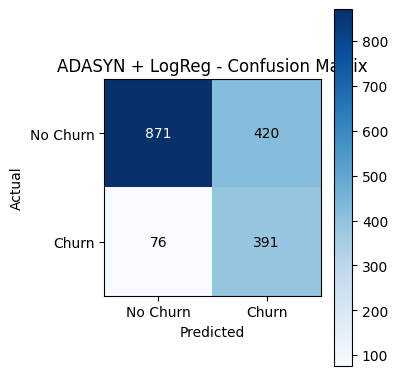

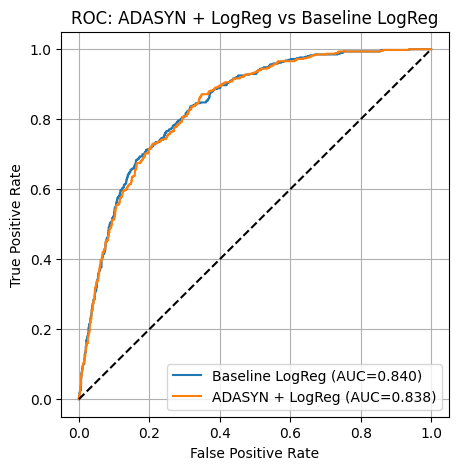

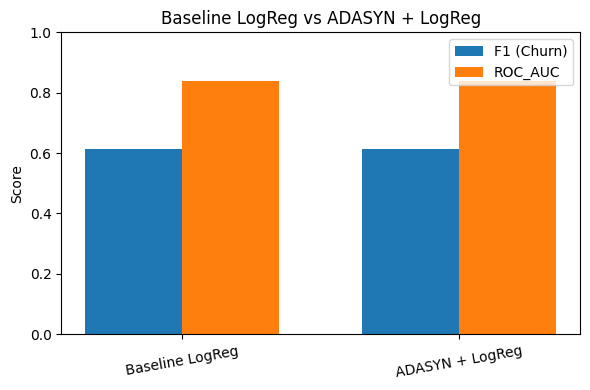

/usr/local/lib/python3.12/dist-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/_tags.py:354: FutureWarning: The ADASYN or classes from which it inherits use `_get_tags` and `_more_tags`. Please define the `__sklearn_tags__` method, or inherit from `sklearn.base.BaseEstimator` and/or other appropriate mixins such as `sklearn.base.TransformerMixin`, `sklearn.base.ClassifierMixin`, `sklearn.base.RegressorMixin`, and `sklearn.base.OutlierMixin`. From scikit-learn 1.7, not defining `__sklearn_tags__` will raise an error.
  warnings.warn(



===== ADASYN + DecisionTree =====
              precision    recall  f1-score   support

    No Churn       0.82      0.80      0.81      1291
       Churn       0.48      0.53      0.51       467

    accuracy                           0.73      1758
   macro avg       0.65      0.66      0.66      1758
weighted avg       0.73      0.73      0.73      1758

ADASYN + DecisionTree F1 (Churn): 0.5066
ADASYN + DecisionTree ROC_AUC   : 0.6638


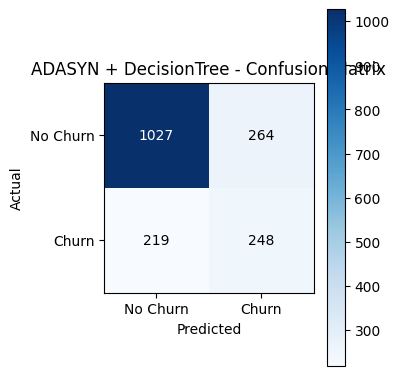

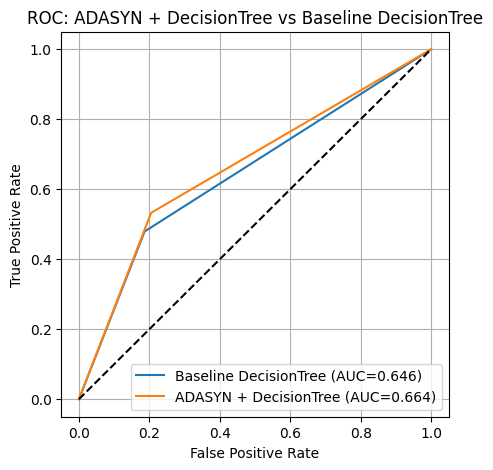

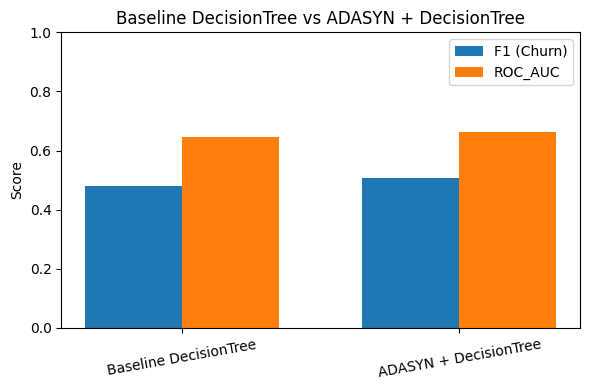

/usr/local/lib/python3.12/dist-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/_tags.py:354: FutureWarning: The ADASYN or classes from which it inherits use `_get_tags` and `_more_tags`. Please define the `__sklearn_tags__` method, or inherit from `sklearn.base.BaseEstimator` and/or other appropriate mixins such as `sklearn.base.TransformerMixin`, `sklearn.base.ClassifierMixin`, `sklearn.base.RegressorMixin`, and `sklearn.base.OutlierMixin`. From scikit-learn 1.7, not defining `__sklearn_tags__` will raise an error.
  warnings.warn(



===== ADASYN + RandomForest =====
              precision    recall  f1-score   support

    No Churn       0.84      0.84      0.84      1291
       Churn       0.56      0.55      0.55       467

    accuracy                           0.76      1758
   macro avg       0.70      0.69      0.70      1758
weighted avg       0.76      0.76      0.76      1758

ADASYN + RandomForest F1 (Churn): 0.5519
ADASYN + RandomForest ROC_AUC   : 0.8030


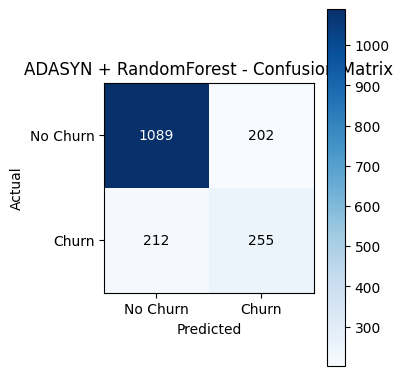

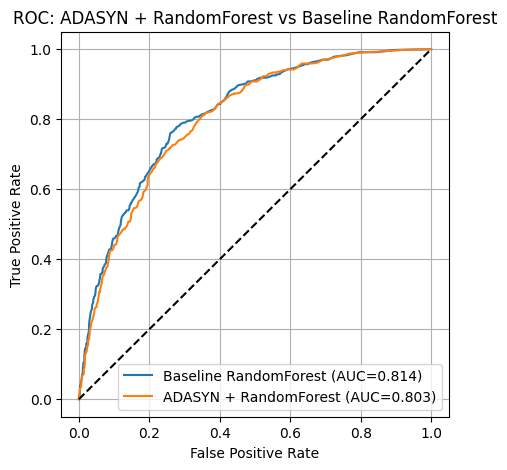

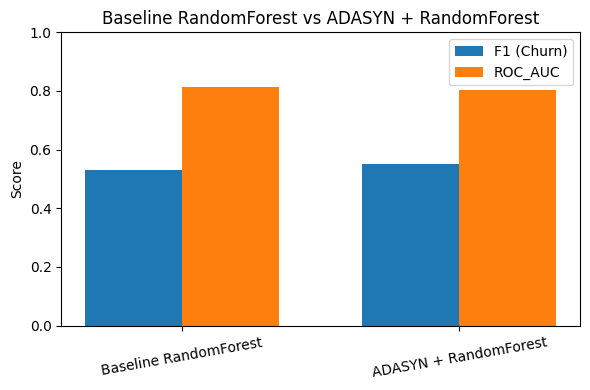

/usr/local/lib/python3.12/dist-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/_tags.py:354: FutureWarning: The ADASYN or classes from which it inherits use `_get_tags` and `_more_tags`. Please define the `__sklearn_tags__` method, or inherit from `sklearn.base.BaseEstimator` and/or other appropriate mixins such as `sklearn.base.TransformerMixin`, `sklearn.base.ClassifierMixin`, `sklearn.base.RegressorMixin`, and `sklearn.base.OutlierMixin`. From scikit-learn 1.7, not defining `__sklearn_tags__` will raise an error.
  warnings.warn(



===== ADASYN + SVM =====
              precision    recall  f1-score   support

    No Churn       0.90      0.73      0.80      1291
       Churn       0.51      0.77      0.61       467

    accuracy                           0.74      1758
   macro avg       0.70      0.75      0.71      1758
weighted avg       0.79      0.74      0.75      1758

ADASYN + SVM F1 (Churn): 0.6094
ADASYN + SVM ROC_AUC   : 0.8162


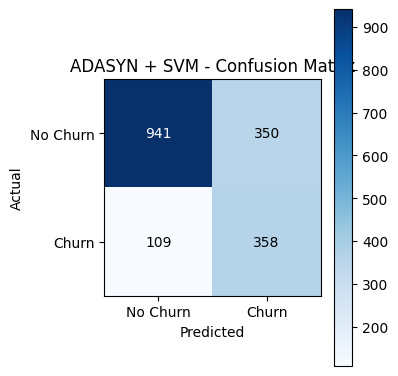

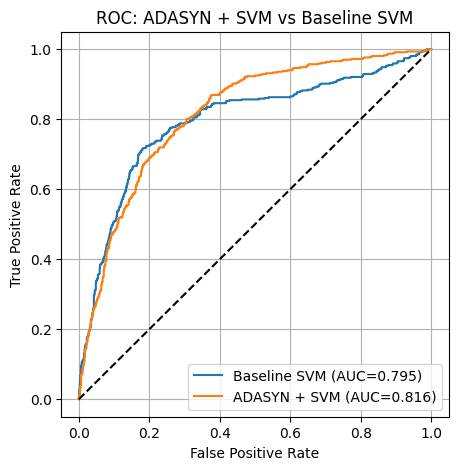

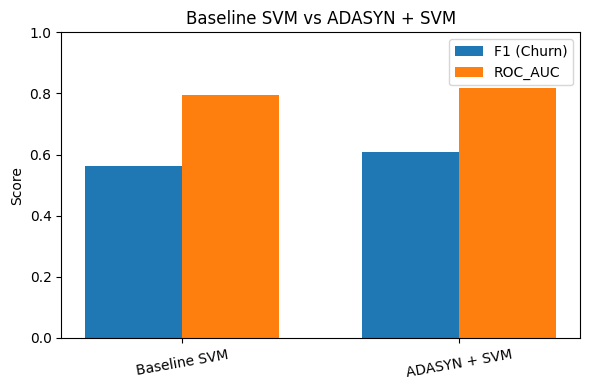

In [ ]:
# ===== ADASYN + 4 Models =====
adasyn_logreg_results = compare_with_baseline(
    sampler_name="ADASYN",
    sampler=ADASYN(random_state=42),
    model_name="LogReg"
)

adasyn_dt_results = compare_with_baseline(
    sampler_name="ADASYN",
    sampler=ADASYN(random_state=42),
    model_name="DecisionTree"
)

adasyn_rf_results = compare_with_baseline(
    sampler_name="ADASYN",
    sampler=ADASYN(random_state=42),
    model_name="RandomForest"
)

adasyn_svm_results = compare_with_baseline(
    sampler_name="ADASYN",
    sampler=ADASYN(random_state=42),
    model_name="SVM"
)


/usr/local/lib/python3.12/dist-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/_tags.py:354: FutureWarning: The SMOTETomek or classes from which it inherits use `_get_tags` and `_more_tags`. Please define the `__sklearn_tags__` method, or inherit from `sklearn.base.BaseEstimator` and/or other appropriate mixins such as `sklearn.base.TransformerMixin`, `sklearn.base.ClassifierMixin`, `sklearn.base.RegressorMixin`, and `sklearn.base.OutlierMixin`. From scikit-learn 1.7, not defining `__sklearn_tags__` will raise an error.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.vali


===== SMOTE-Tomek + LogReg =====
              precision    recall  f1-score   support

    No Churn       0.91      0.71      0.80      1291
       Churn       0.50      0.80      0.62       467

    accuracy                           0.74      1758
   macro avg       0.70      0.76      0.71      1758
weighted avg       0.80      0.74      0.75      1758

SMOTE-Tomek + LogReg F1 (Churn): 0.6164
SMOTE-Tomek + LogReg ROC_AUC   : 0.8393


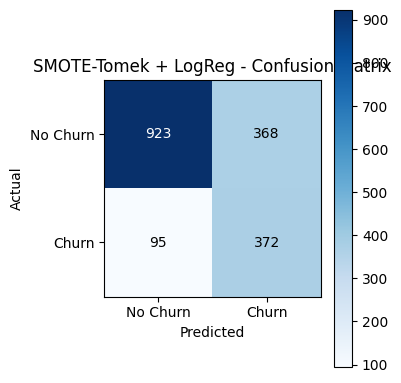

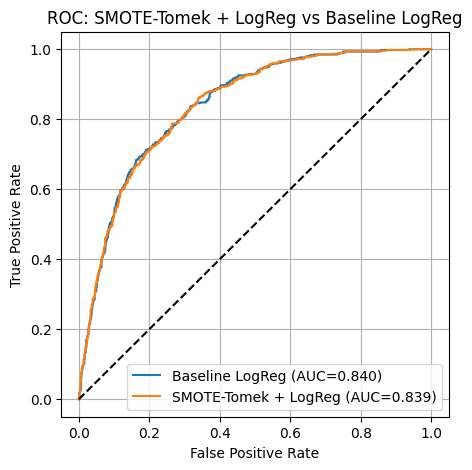

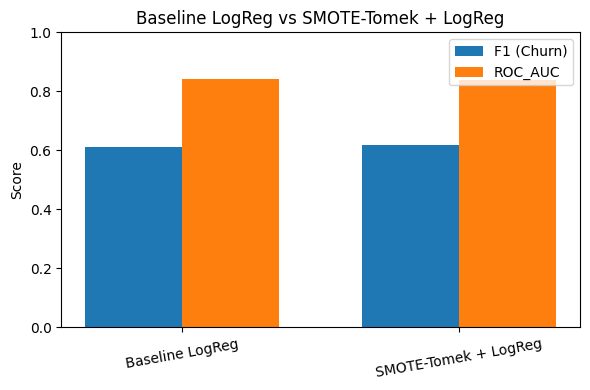

/usr/local/lib/python3.12/dist-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/_tags.py:354: FutureWarning: The SMOTETomek or classes from which it inherits use `_get_tags` and `_more_tags`. Please define the `__sklearn_tags__` method, or inherit from `sklearn.base.BaseEstimator` and/or other appropriate mixins such as `sklearn.base.TransformerMixin`, `sklearn.base.ClassifierMixin`, `sklearn.base.RegressorMixin`, and `sklearn.base.OutlierMixin`. From scikit-learn 1.7, not defining `__sklearn_tags__` will raise an error.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.vali


===== SMOTE-Tomek + DecisionTree =====
              precision    recall  f1-score   support

    No Churn       0.83      0.80      0.82      1291
       Churn       0.50      0.56      0.53       467

    accuracy                           0.73      1758
   macro avg       0.67      0.68      0.67      1758
weighted avg       0.75      0.73      0.74      1758

SMOTE-Tomek + DecisionTree F1 (Churn): 0.5293
SMOTE-Tomek + DecisionTree ROC_AUC   : 0.6791


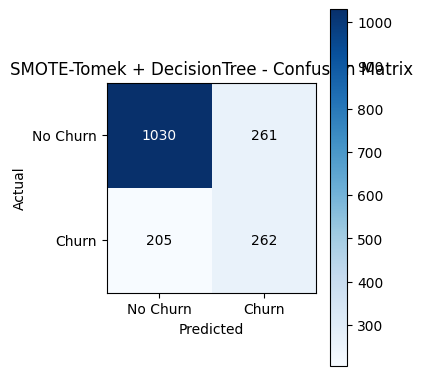

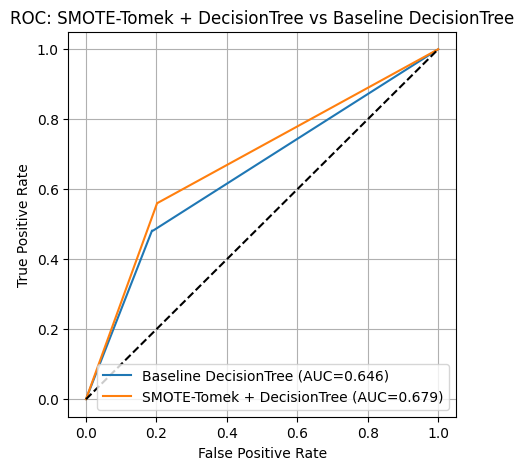

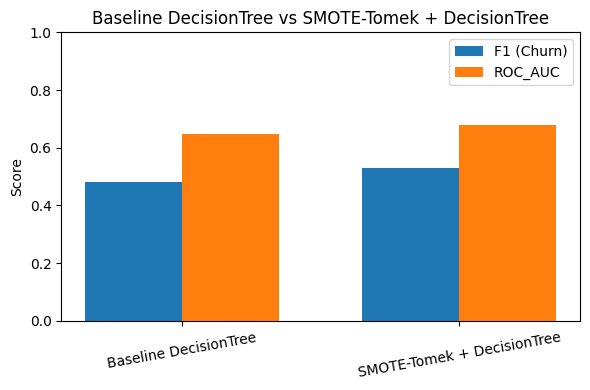

/usr/local/lib/python3.12/dist-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/_tags.py:354: FutureWarning: The SMOTETomek or classes from which it inherits use `_get_tags` and `_more_tags`. Please define the `__sklearn_tags__` method, or inherit from `sklearn.base.BaseEstimator` and/or other appropriate mixins such as `sklearn.base.TransformerMixin`, `sklearn.base.ClassifierMixin`, `sklearn.base.RegressorMixin`, and `sklearn.base.OutlierMixin`. From scikit-learn 1.7, not defining `__sklearn_tags__` will raise an error.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.vali


===== SMOTE-Tomek + RandomForest =====
              precision    recall  f1-score   support

    No Churn       0.84      0.85      0.84      1291
       Churn       0.57      0.55      0.56       467

    accuracy                           0.77      1758
   macro avg       0.70      0.70      0.70      1758
weighted avg       0.77      0.77      0.77      1758

SMOTE-Tomek + RandomForest F1 (Churn): 0.5612
SMOTE-Tomek + RandomForest ROC_AUC   : 0.8169


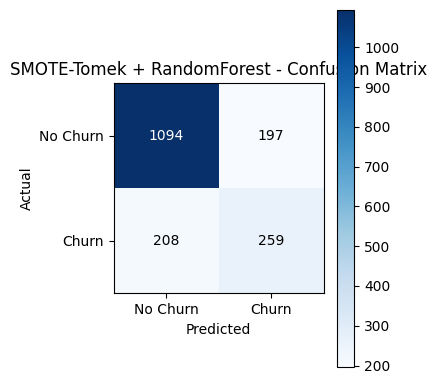

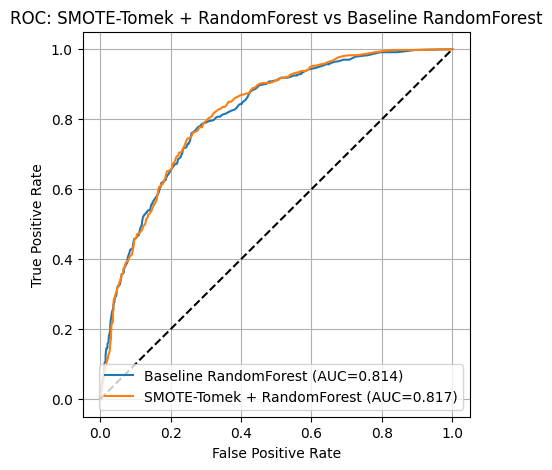

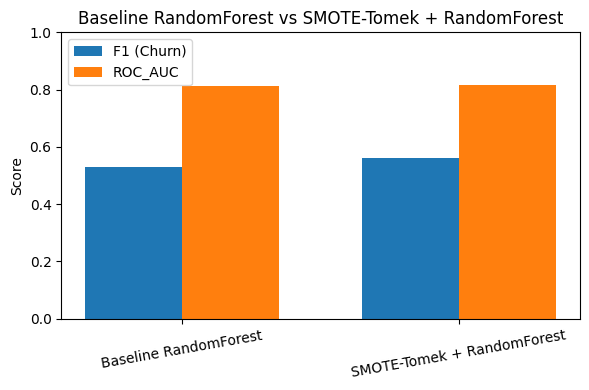

/usr/local/lib/python3.12/dist-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/_tags.py:354: FutureWarning: The SMOTETomek or classes from which it inherits use `_get_tags` and `_more_tags`. Please define the `__sklearn_tags__` method, or inherit from `sklearn.base.BaseEstimator` and/or other appropriate mixins such as `sklearn.base.TransformerMixin`, `sklearn.base.ClassifierMixin`, `sklearn.base.RegressorMixin`, and `sklearn.base.OutlierMixin`. From scikit-learn 1.7, not defining `__sklearn_tags__` will raise an error.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.vali


===== SMOTE-Tomek + SVM =====
              precision    recall  f1-score   support

    No Churn       0.89      0.76      0.82      1291
       Churn       0.53      0.75      0.62       467

    accuracy                           0.75      1758
   macro avg       0.71      0.75      0.72      1758
weighted avg       0.79      0.75      0.77      1758

SMOTE-Tomek + SVM F1 (Churn): 0.6176
SMOTE-Tomek + SVM ROC_AUC   : 0.8150


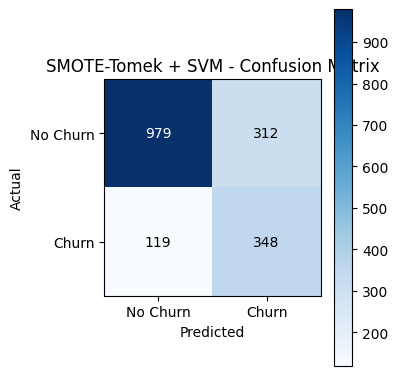

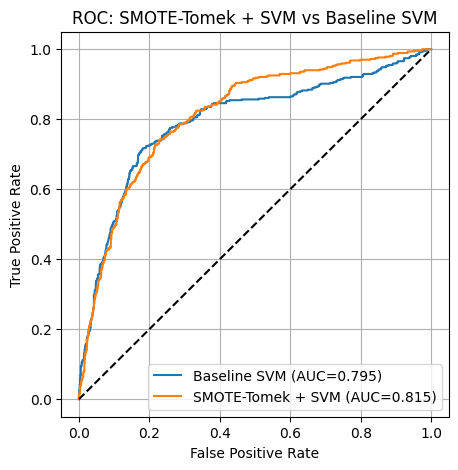

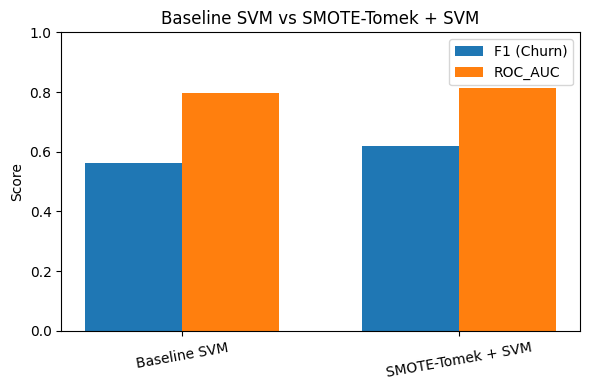

In [ ]:
# ===== SMOTE-Tomek + 4 Models =====
smote_tomek_logreg_results = compare_with_baseline(
    sampler_name="SMOTE-Tomek",
    sampler=SMOTETomek(random_state=42),
    model_name="LogReg"
)

smote_tomek_dt_results = compare_with_baseline(
    sampler_name="SMOTE-Tomek",
    sampler=SMOTETomek(random_state=42),
    model_name="DecisionTree"
)

smote_tomek_rf_results = compare_with_baseline(
    sampler_name="SMOTE-Tomek",
    sampler=SMOTETomek(random_state=42),
    model_name="RandomForest"
)

smote_tomek_svm_results = compare_with_baseline(
    sampler_name="SMOTE-Tomek",
    sampler=SMOTETomek(random_state=42),
    model_name="SVM"
)


/usr/local/lib/python3.12/dist-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/_tags.py:354: FutureWarning: The SMOTEENN or classes from which it inherits use `_get_tags` and `_more_tags`. Please define the `__sklearn_tags__` method, or inherit from `sklearn.base.BaseEstimator` and/or other appropriate mixins such as `sklearn.base.TransformerMixin`, `sklearn.base.ClassifierMixin`, `sklearn.base.RegressorMixin`, and `sklearn.base.OutlierMixin`. From scikit-learn 1.7, not defining `__sklearn_tags__` will raise an error.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.valida


===== SMOTE-ENN + LogReg =====
              precision    recall  f1-score   support

    No Churn       0.92      0.61      0.73      1291
       Churn       0.44      0.86      0.59       467

    accuracy                           0.68      1758
   macro avg       0.68      0.74      0.66      1758
weighted avg       0.80      0.68      0.69      1758

SMOTE-ENN + LogReg F1 (Churn): 0.5856
SMOTE-ENN + LogReg ROC_AUC   : 0.8354


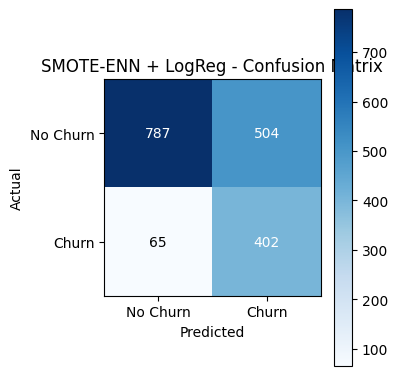

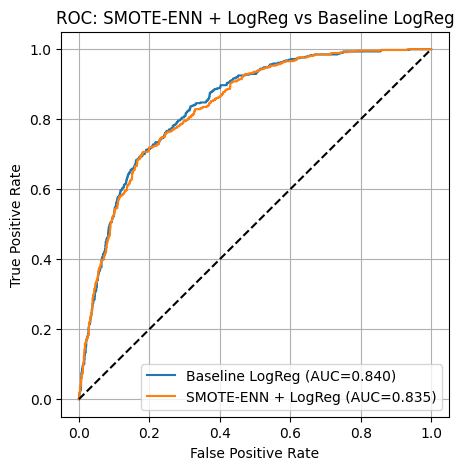

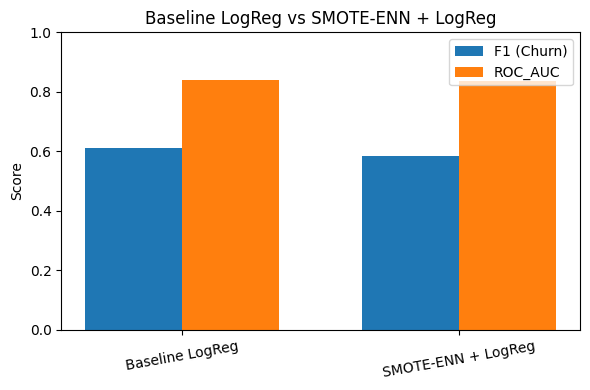

/usr/local/lib/python3.12/dist-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/_tags.py:354: FutureWarning: The SMOTEENN or classes from which it inherits use `_get_tags` and `_more_tags`. Please define the `__sklearn_tags__` method, or inherit from `sklearn.base.BaseEstimator` and/or other appropriate mixins such as `sklearn.base.TransformerMixin`, `sklearn.base.ClassifierMixin`, `sklearn.base.RegressorMixin`, and `sklearn.base.OutlierMixin`. From scikit-learn 1.7, not defining `__sklearn_tags__` will raise an error.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.valida


===== SMOTE-ENN + DecisionTree =====
              precision    recall  f1-score   support

    No Churn       0.89      0.69      0.78      1291
       Churn       0.47      0.77      0.59       467

    accuracy                           0.71      1758
   macro avg       0.68      0.73      0.68      1758
weighted avg       0.78      0.71      0.73      1758

SMOTE-ENN + DecisionTree F1 (Churn): 0.5852
SMOTE-ENN + DecisionTree ROC_AUC   : 0.7291


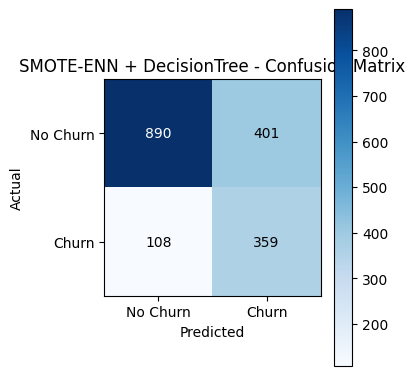

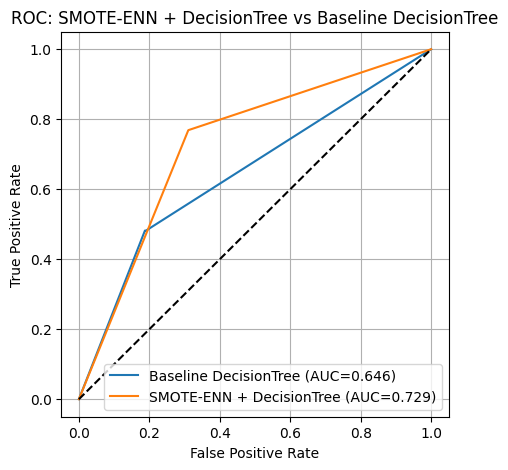

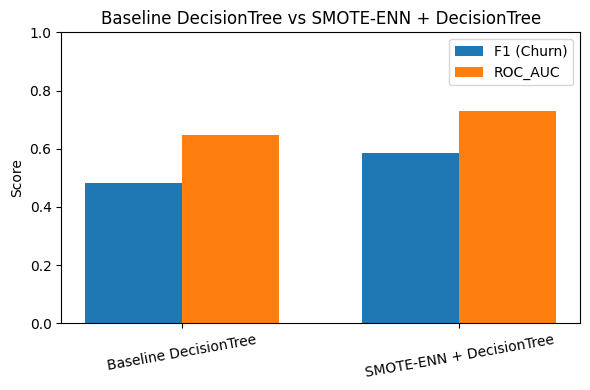

/usr/local/lib/python3.12/dist-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/_tags.py:354: FutureWarning: The SMOTEENN or classes from which it inherits use `_get_tags` and `_more_tags`. Please define the `__sklearn_tags__` method, or inherit from `sklearn.base.BaseEstimator` and/or other appropriate mixins such as `sklearn.base.TransformerMixin`, `sklearn.base.ClassifierMixin`, `sklearn.base.RegressorMixin`, and `sklearn.base.OutlierMixin`. From scikit-learn 1.7, not defining `__sklearn_tags__` will raise an error.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.valida


===== SMOTE-ENN + RandomForest =====
              precision    recall  f1-score   support

    No Churn       0.91      0.69      0.78      1291
       Churn       0.48      0.82      0.61       467

    accuracy                           0.72      1758
   macro avg       0.70      0.75      0.70      1758
weighted avg       0.80      0.72      0.74      1758

SMOTE-ENN + RandomForest F1 (Churn): 0.6088
SMOTE-ENN + RandomForest ROC_AUC   : 0.8275


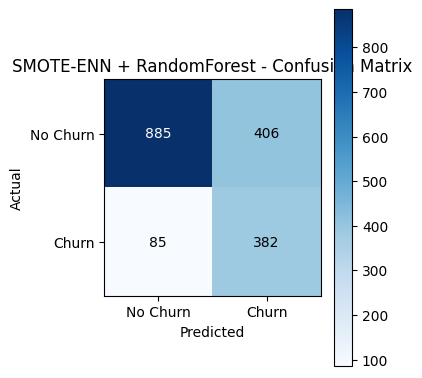

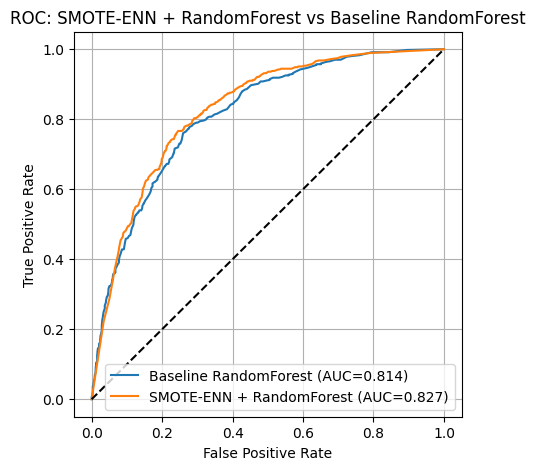

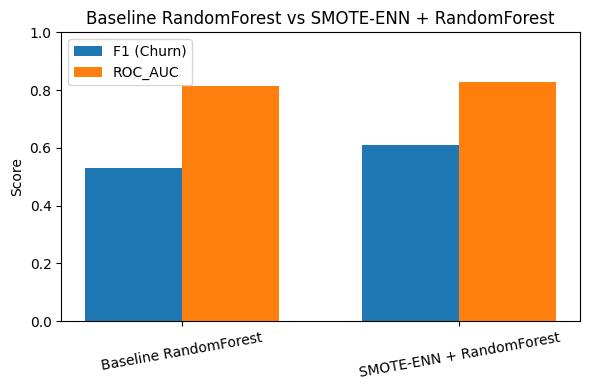

/usr/local/lib/python3.12/dist-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/_tags.py:354: FutureWarning: The SMOTEENN or classes from which it inherits use `_get_tags` and `_more_tags`. Please define the `__sklearn_tags__` method, or inherit from `sklearn.base.BaseEstimator` and/or other appropriate mixins such as `sklearn.base.TransformerMixin`, `sklearn.base.ClassifierMixin`, `sklearn.base.RegressorMixin`, and `sklearn.base.OutlierMixin`. From scikit-learn 1.7, not defining `__sklearn_tags__` will raise an error.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.valida


===== SMOTE-ENN + SVM =====
              precision    recall  f1-score   support

    No Churn       0.91      0.65      0.76      1291
       Churn       0.46      0.83      0.59       467

    accuracy                           0.69      1758
   macro avg       0.69      0.74      0.67      1758
weighted avg       0.79      0.69      0.71      1758

SMOTE-ENN + SVM F1 (Churn): 0.5898
SMOTE-ENN + SVM ROC_AUC   : 0.8208


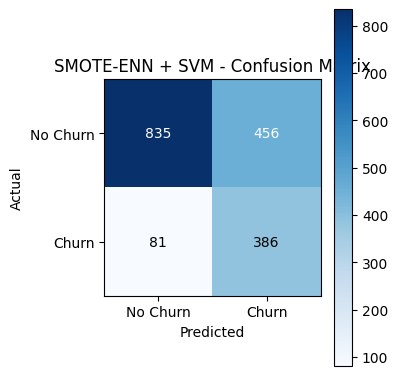

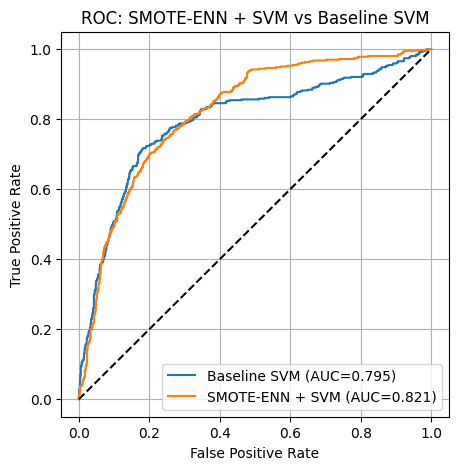

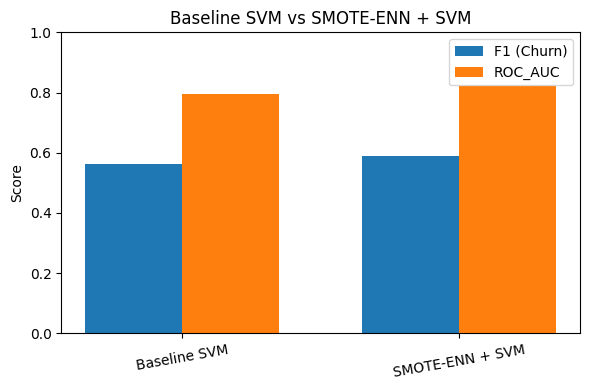

In [ ]:
# ===== SMOTE-ENN + 4 Models =====
smote_enn_logreg_results = compare_with_baseline(
    sampler_name="SMOTE-ENN",
    sampler=SMOTEENN(random_state=42),
    model_name="LogReg"
)

smote_enn_dt_results = compare_with_baseline(
    sampler_name="SMOTE-ENN",
    sampler=SMOTEENN(random_state=42),
    model_name="DecisionTree"
)

smote_enn_rf_results = compare_with_baseline(
    sampler_name="SMOTE-ENN",
    sampler=SMOTEENN(random_state=42),
    model_name="RandomForest"
)

smote_enn_svm_results = compare_with_baseline(
    sampler_name="SMOTE-ENN",
    sampler=SMOTEENN(random_state=42),
    model_name="SVM"
)


/usr/local/lib/python3.12/dist-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/_tags.py:354: FutureWarning: The KMeansSMOTE or classes from which it inherits use `_get_tags` and `_more_tags`. Please define the `__sklearn_tags__` method, or inherit from `sklearn.base.BaseEstimator` and/or other appropriate mixins such as `sklearn.base.TransformerMixin`, `sklearn.base.ClassifierMixin`, `sklearn.base.RegressorMixin`, and `sklearn.base.OutlierMixin`. From scikit-learn 1.7, not defining `__sklearn_tags__` will raise an error.
  warnings.warn(



===== Cluster-SMOTE + LogReg =====
              precision    recall  f1-score   support

    No Churn       0.88      0.83      0.86      1291
       Churn       0.60      0.69      0.64       467

    accuracy                           0.80      1758
   macro avg       0.74      0.76      0.75      1758
weighted avg       0.81      0.80      0.80      1758

Cluster-SMOTE + LogReg F1 (Churn): 0.6441
Cluster-SMOTE + LogReg ROC_AUC   : 0.8364


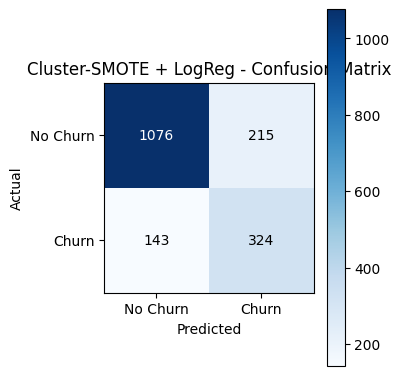

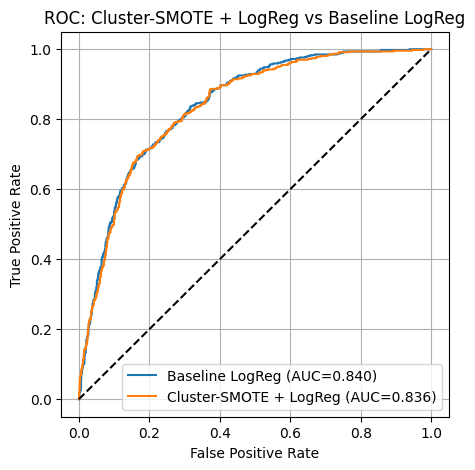

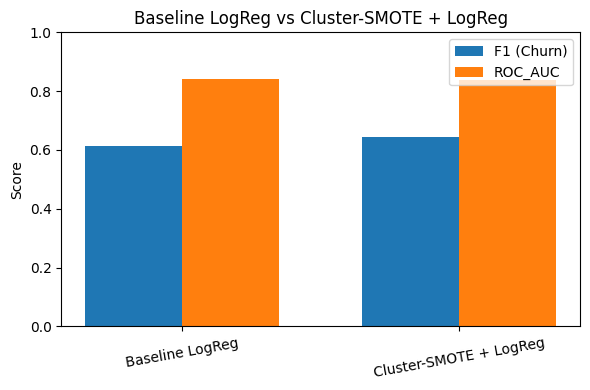

/usr/local/lib/python3.12/dist-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/_tags.py:354: FutureWarning: The KMeansSMOTE or classes from which it inherits use `_get_tags` and `_more_tags`. Please define the `__sklearn_tags__` method, or inherit from `sklearn.base.BaseEstimator` and/or other appropriate mixins such as `sklearn.base.TransformerMixin`, `sklearn.base.ClassifierMixin`, `sklearn.base.RegressorMixin`, and `sklearn.base.OutlierMixin`. From scikit-learn 1.7, not defining `__sklearn_tags__` will raise an error.
  warnings.warn(



===== Cluster-SMOTE + DecisionTree =====
              precision    recall  f1-score   support

    No Churn       0.83      0.81      0.82      1291
       Churn       0.50      0.53      0.52       467

    accuracy                           0.73      1758
   macro avg       0.66      0.67      0.67      1758
weighted avg       0.74      0.73      0.74      1758

Cluster-SMOTE + DecisionTree F1 (Churn): 0.5166
Cluster-SMOTE + DecisionTree ROC_AUC   : 0.6702


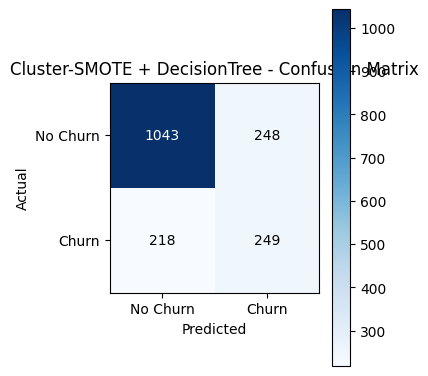

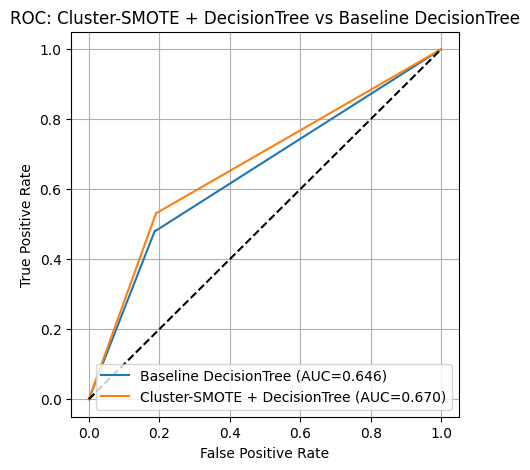

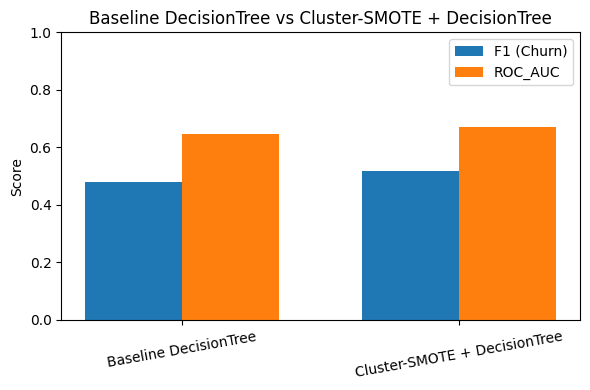

/usr/local/lib/python3.12/dist-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/_tags.py:354: FutureWarning: The KMeansSMOTE or classes from which it inherits use `_get_tags` and `_more_tags`. Please define the `__sklearn_tags__` method, or inherit from `sklearn.base.BaseEstimator` and/or other appropriate mixins such as `sklearn.base.TransformerMixin`, `sklearn.base.ClassifierMixin`, `sklearn.base.RegressorMixin`, and `sklearn.base.OutlierMixin`. From scikit-learn 1.7, not defining `__sklearn_tags__` will raise an error.
  warnings.warn(



===== Cluster-SMOTE + RandomForest =====
              precision    recall  f1-score   support

    No Churn       0.83      0.87      0.85      1291
       Churn       0.59      0.52      0.56       467

    accuracy                           0.78      1758
   macro avg       0.71      0.70      0.70      1758
weighted avg       0.77      0.78      0.77      1758

Cluster-SMOTE + RandomForest F1 (Churn): 0.5558
Cluster-SMOTE + RandomForest ROC_AUC   : 0.8128


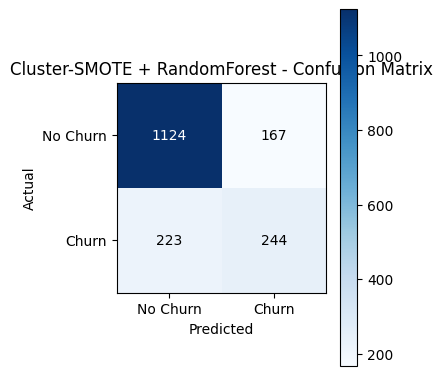

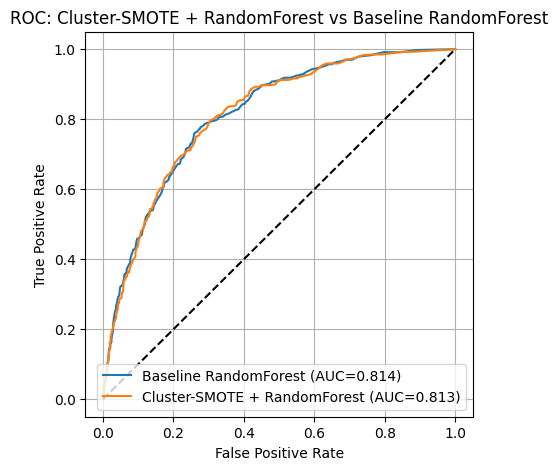

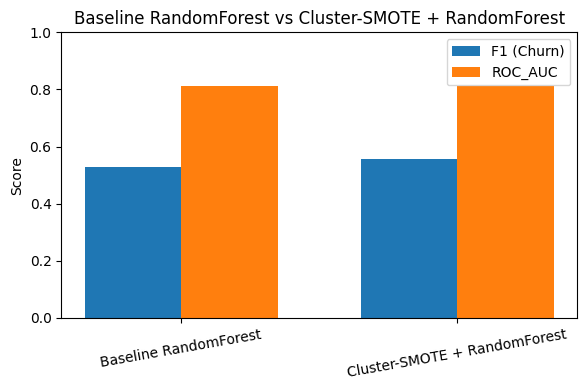

/usr/local/lib/python3.12/dist-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/_tags.py:354: FutureWarning: The KMeansSMOTE or classes from which it inherits use `_get_tags` and `_more_tags`. Please define the `__sklearn_tags__` method, or inherit from `sklearn.base.BaseEstimator` and/or other appropriate mixins such as `sklearn.base.TransformerMixin`, `sklearn.base.ClassifierMixin`, `sklearn.base.RegressorMixin`, and `sklearn.base.OutlierMixin`. From scikit-learn 1.7, not defining `__sklearn_tags__` will raise an error.
  warnings.warn(



===== Cluster-SMOTE + SVM =====
              precision    recall  f1-score   support

    No Churn       0.85      0.87      0.86      1291
       Churn       0.61      0.57      0.59       467

    accuracy                           0.79      1758
   macro avg       0.73      0.72      0.72      1758
weighted avg       0.78      0.79      0.79      1758

Cluster-SMOTE + SVM F1 (Churn): 0.5888
Cluster-SMOTE + SVM ROC_AUC   : 0.7953


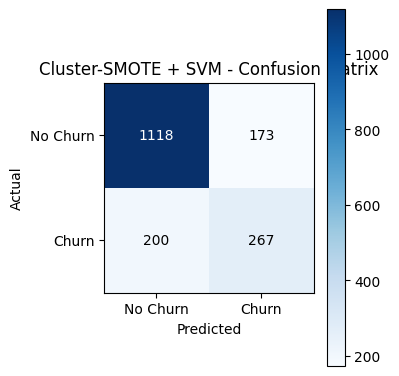

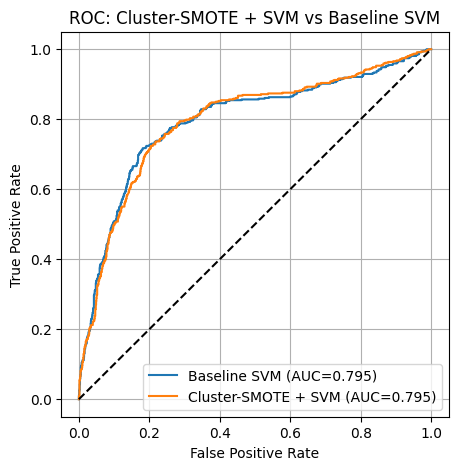

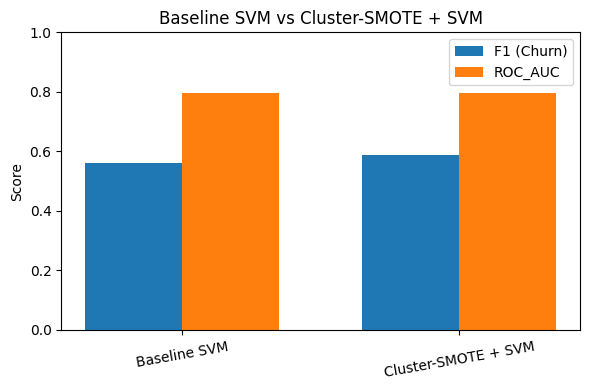

In [ ]:
# ===== Cluster-SMOTE (KMeansSMOTE) + 4 Models =====
cluster_smote_logreg_results = compare_with_baseline(
    sampler_name="Cluster-SMOTE",
    sampler=KMeansSMOTE(random_state=42),
    model_name="LogReg"
)

cluster_smote_dt_results = compare_with_baseline(
    sampler_name="Cluster-SMOTE",
    sampler=KMeansSMOTE(random_state=42),
    model_name="DecisionTree"
)

cluster_smote_rf_results = compare_with_baseline(
    sampler_name="Cluster-SMOTE",
    sampler=KMeansSMOTE(random_state=42),
    model_name="RandomForest"
)

cluster_smote_svm_results = compare_with_baseline(
    sampler_name="Cluster-SMOTE",
    sampler=KMeansSMOTE(random_state=42),
    model_name="SVM"
)


/usr/local/lib/python3.12/dist-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/_tags.py:354: FutureWarning: The MajorityDensityOverSampler or classes from which it inherits use `_get_tags` and `_more_tags`. Please define the `__sklearn_tags__` method, or inherit from `sklearn.base.BaseEstimator` and/or other appropriate mixins such as `sklearn.base.TransformerMixin`, `sklearn.base.ClassifierMixin`, `sklearn.base.RegressorMixin`, and `sklearn.base.OutlierMixin`. From scikit-learn 1.7, not defining `__sklearn_tags__` will raise an error.
  warnings.warn(



===== MajorityDensity + LogReg =====
              precision    recall  f1-score   support

    No Churn       0.85      0.89      0.87      1291
       Churn       0.66      0.57      0.61       467

    accuracy                           0.81      1758
   macro avg       0.75      0.73      0.74      1758
weighted avg       0.80      0.81      0.80      1758

MajorityDensity + LogReg F1 (Churn): 0.6119
MajorityDensity + LogReg ROC_AUC   : 0.8402


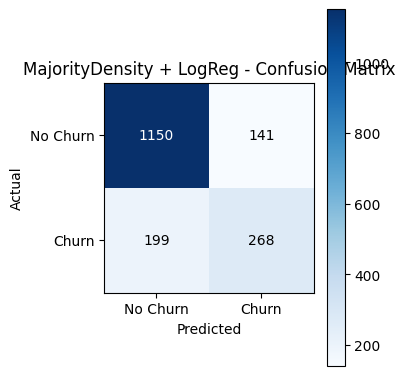

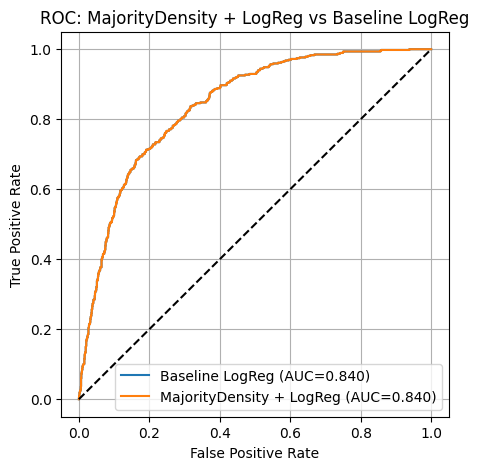

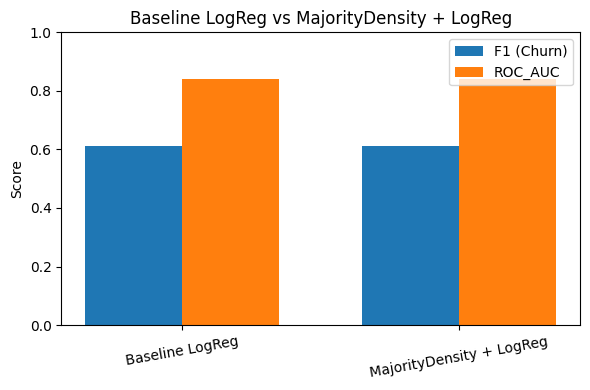


===== MajorityDensity + DecisionTree =====
              precision    recall  f1-score   support

    No Churn       0.81      0.81      0.81      1291
       Churn       0.48      0.48      0.48       467

    accuracy                           0.72      1758
   macro avg       0.65      0.65      0.65      1758
weighted avg       0.72      0.72      0.72      1758

MajorityDensity + DecisionTree F1 (Churn): 0.4813
MajorityDensity + DecisionTree ROC_AUC   : 0.6464


/usr/local/lib/python3.12/dist-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/_tags.py:354: FutureWarning: The MajorityDensityOverSampler or classes from which it inherits use `_get_tags` and `_more_tags`. Please define the `__sklearn_tags__` method, or inherit from `sklearn.base.BaseEstimator` and/or other appropriate mixins such as `sklearn.base.TransformerMixin`, `sklearn.base.ClassifierMixin`, `sklearn.base.RegressorMixin`, and `sklearn.base.OutlierMixin`. From scikit-learn 1.7, not defining `__sklearn_tags__` will raise an error.
  warnings.warn(


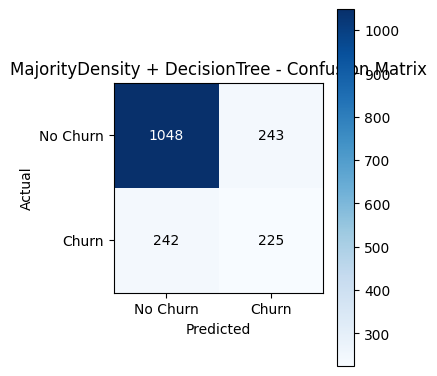

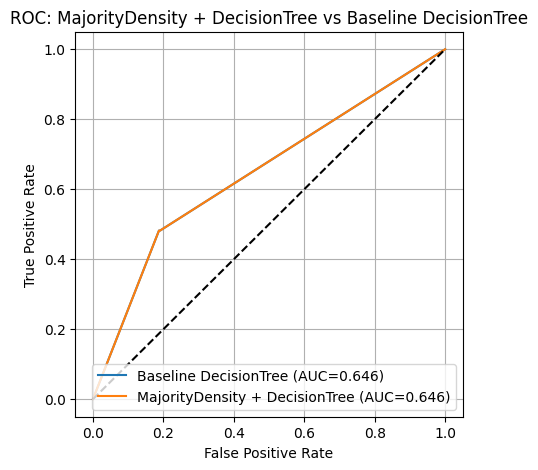

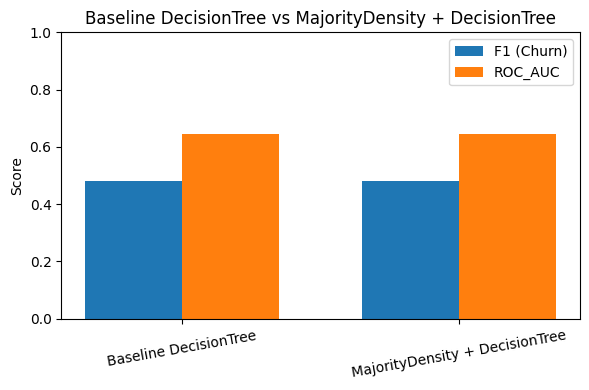

/usr/local/lib/python3.12/dist-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/_tags.py:354: FutureWarning: The MajorityDensityOverSampler or classes from which it inherits use `_get_tags` and `_more_tags`. Please define the `__sklearn_tags__` method, or inherit from `sklearn.base.BaseEstimator` and/or other appropriate mixins such as `sklearn.base.TransformerMixin`, `sklearn.base.ClassifierMixin`, `sklearn.base.RegressorMixin`, and `sklearn.base.OutlierMixin`. From scikit-learn 1.7, not defining `__sklearn_tags__` will raise an error.
  warnings.warn(



===== MajorityDensity + RandomForest =====
              precision    recall  f1-score   support

    No Churn       0.82      0.89      0.85      1291
       Churn       0.61      0.47      0.53       467

    accuracy                           0.78      1758
   macro avg       0.71      0.68      0.69      1758
weighted avg       0.77      0.78      0.77      1758

MajorityDensity + RandomForest F1 (Churn): 0.5290
MajorityDensity + RandomForest ROC_AUC   : 0.8136


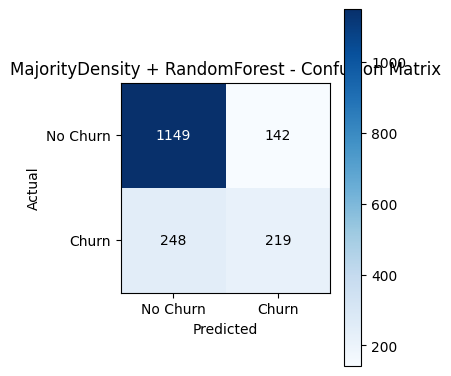

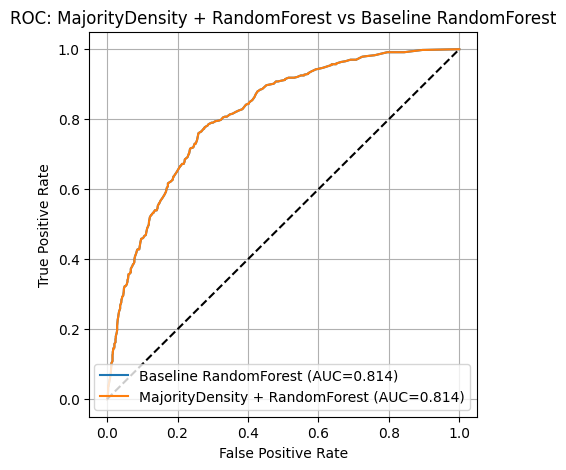

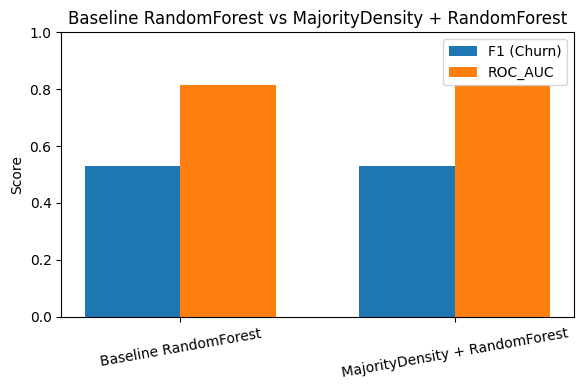

/usr/local/lib/python3.12/dist-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/_tags.py:354: FutureWarning: The MajorityDensityOverSampler or classes from which it inherits use `_get_tags` and `_more_tags`. Please define the `__sklearn_tags__` method, or inherit from `sklearn.base.BaseEstimator` and/or other appropriate mixins such as `sklearn.base.TransformerMixin`, `sklearn.base.ClassifierMixin`, `sklearn.base.RegressorMixin`, and `sklearn.base.OutlierMixin`. From scikit-learn 1.7, not defining `__sklearn_tags__` will raise an error.
  warnings.warn(



===== MajorityDensity + SVM =====
              precision    recall  f1-score   support

    No Churn       0.83      0.91      0.87      1291
       Churn       0.66      0.49      0.56       467

    accuracy                           0.80      1758
   macro avg       0.74      0.70      0.71      1758
weighted avg       0.79      0.80      0.79      1758

MajorityDensity + SVM F1 (Churn): 0.5620
MajorityDensity + SVM ROC_AUC   : 0.7955


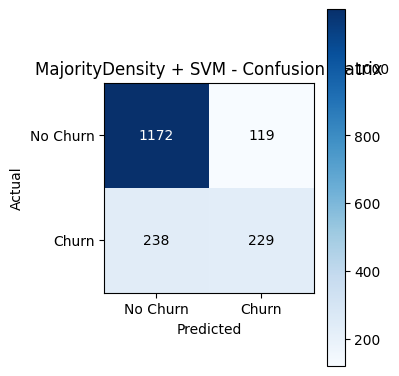

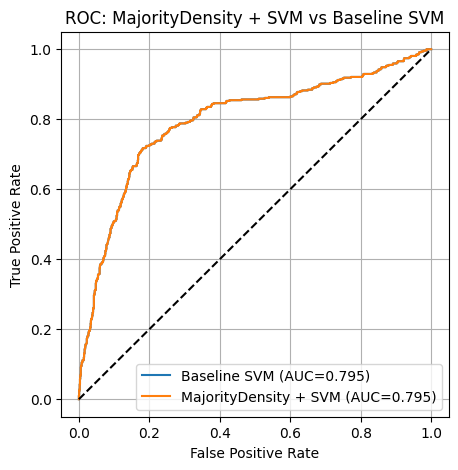

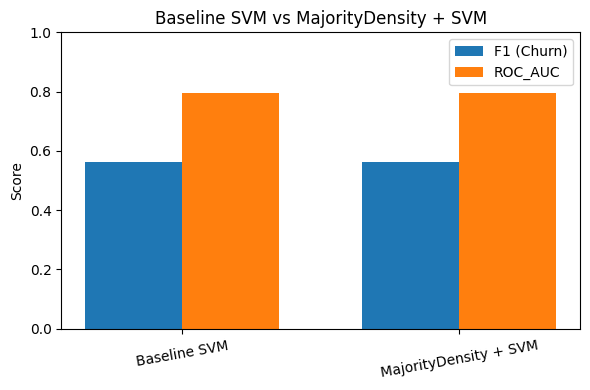

In [ ]:
from sklearn.base import BaseEstimator
from imblearn.base import SamplerMixin, BaseSampler # Import BaseSampler
import numpy as np

# Placeholder for MajorityDensityOverSampler
class MajorityDensityOverSampler(BaseSampler): # Inherit from BaseSampler
    """
    A placeholder for a custom Majority Density Oversampler.
    This implementation currently does not perform any actual oversampling.
    Users should replace this with their custom oversampling logic.
    """
    _sampling_type = "over-sampling" # Define sampling type

    def __init__(self, random_state=None):
        super().__init__() # Call BaseSampler's init without random_state
        self.random_state = random_state # Store random_state as an attribute

    def _fit_resample(self, X, y):
        # This is a placeholder. In a real implementation, you would
        # implement your oversampling logic here. For now, it just
        # returns the original data.
        return X, y

# Placeholder for VAESMOTE
class VAESMOTE(BaseSampler):
    """
    A placeholder for a custom VAE-SMOTE oversampler.
    This implementation currently does not perform any actual oversampling.
    Users should replace this with their custom VAE-SMOTE logic.
    """
    _sampling_type = "over-sampling"

    def __init__(self, random_state=None):
        super().__init__()
        self.random_state = random_state

    def _fit_resample(self, X, y):
        # This is a placeholder. Implement actual VAE-SMOTE logic here.
        return X, y

# Placeholder for GANOversampler
class GANOversampler(BaseSampler):
    """
    A placeholder for a custom GAN-based oversampler.
    This implementation currently does not perform any actual oversampling.
    Users should replace this with their custom GAN oversampling logic.
    """
    _sampling_type = "over-sampling"

    def __init__(self, random_state=None):
        super().__init__()
        self.random_state = random_state

    def _fit_resample(self, X, y):
        # This is a placeholder. Implement actual GAN oversampling logic here.
        return X, y


# ===== Majority Density Oversampler + 4 Models =====
majority_density_logreg_results = compare_with_baseline(
    sampler_name="MajorityDensity",
    sampler=MajorityDensityOverSampler(random_state=42),
    model_name="LogReg"
)

majority_density_dt_results = compare_with_baseline(
    sampler_name="MajorityDensity",
    sampler=MajorityDensityOverSampler(random_state=42),
    model_name="DecisionTree"
)

majority_density_rf_results = compare_with_baseline(
    sampler_name="MajorityDensity",
    sampler=MajorityDensityOverSampler(random_state=42),
    model_name="RandomForest"
)

majority_density_svm_results = compare_with_baseline(
    sampler_name="MajorityDensity",
    sampler=MajorityDensityOverSampler(random_state=42),
    model_name="SVM"
)


===== NearMiss (v1) + LogReg =====
              precision    recall  f1-score   support

    No Churn       0.90      0.59      0.71      1291
       Churn       0.42      0.82      0.56       467

    accuracy                           0.65      1758
   macro avg       0.66      0.71      0.64      1758
weighted avg       0.77      0.65      0.67      1758

NearMiss (v1) + LogReg F1 (Churn): 0.5556
NearMiss (v1) + LogReg ROC_AUC   : 0.7667


/usr/local/lib/python3.12/dist-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/_tags.py:354: FutureWarning: The NearMiss or classes from which it inherits use `_get_tags` and `_more_tags`. Please define the `__sklearn_tags__` method, or inherit from `sklearn.base.BaseEstimator` and/or other appropriate mixins such as `sklearn.base.TransformerMixin`, `sklearn.base.ClassifierMixin`, `sklearn.base.RegressorMixin`, and `sklearn.base.OutlierMixin`. From scikit-learn 1.7, not defining `__sklearn_tags__` will raise an error.
  warnings.warn(


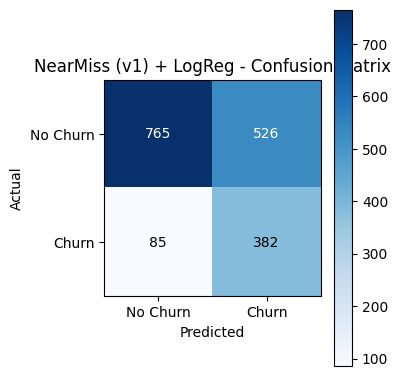

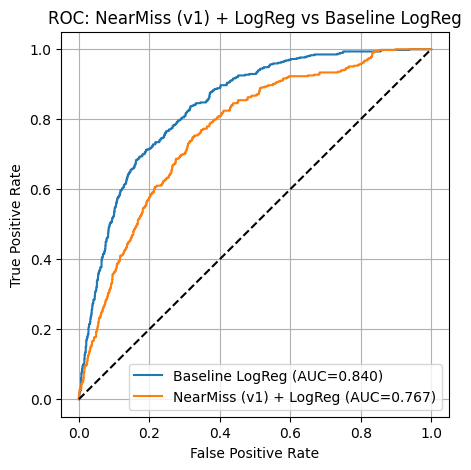

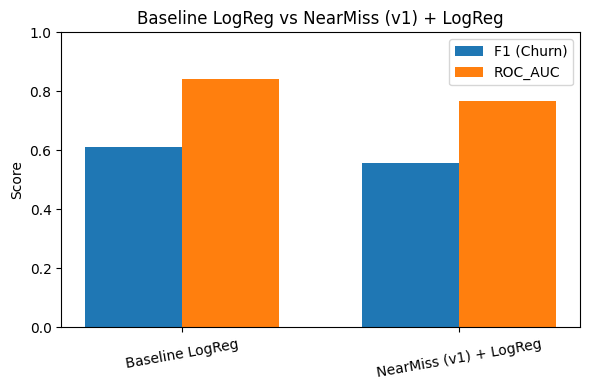


===== NearMiss (v1) + DecisionTree =====
              precision    recall  f1-score   support

    No Churn       0.78      0.46      0.58      1291
       Churn       0.30      0.63      0.41       467

    accuracy                           0.51      1758
   macro avg       0.54      0.55      0.49      1758
weighted avg       0.65      0.51      0.53      1758

NearMiss (v1) + DecisionTree F1 (Churn): 0.4052
NearMiss (v1) + DecisionTree ROC_AUC   : 0.5463


/usr/local/lib/python3.12/dist-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/_tags.py:354: FutureWarning: The NearMiss or classes from which it inherits use `_get_tags` and `_more_tags`. Please define the `__sklearn_tags__` method, or inherit from `sklearn.base.BaseEstimator` and/or other appropriate mixins such as `sklearn.base.TransformerMixin`, `sklearn.base.ClassifierMixin`, `sklearn.base.RegressorMixin`, and `sklearn.base.OutlierMixin`. From scikit-learn 1.7, not defining `__sklearn_tags__` will raise an error.
  warnings.warn(


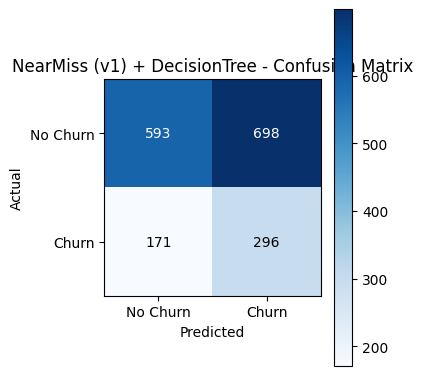

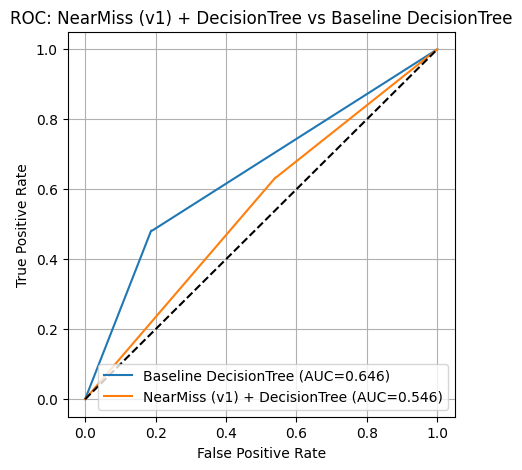

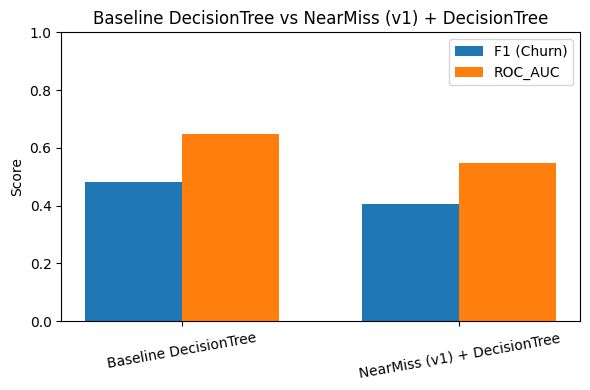

/usr/local/lib/python3.12/dist-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/_tags.py:354: FutureWarning: The NearMiss or classes from which it inherits use `_get_tags` and `_more_tags`. Please define the `__sklearn_tags__` method, or inherit from `sklearn.base.BaseEstimator` and/or other appropriate mixins such as `sklearn.base.TransformerMixin`, `sklearn.base.ClassifierMixin`, `sklearn.base.RegressorMixin`, and `sklearn.base.OutlierMixin`. From scikit-learn 1.7, not defining `__sklearn_tags__` will raise an error.
  warnings.warn(



===== NearMiss (v1) + RandomForest =====
              precision    recall  f1-score   support

    No Churn       0.81      0.43      0.56      1291
       Churn       0.31      0.71      0.43       467

    accuracy                           0.51      1758
   macro avg       0.56      0.57      0.50      1758
weighted avg       0.67      0.51      0.53      1758

NearMiss (v1) + RandomForest F1 (Churn): 0.4342
NearMiss (v1) + RandomForest ROC_AUC   : 0.6192


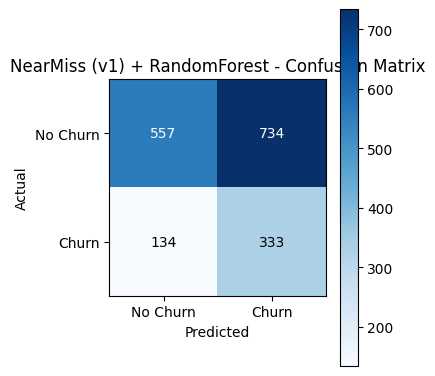

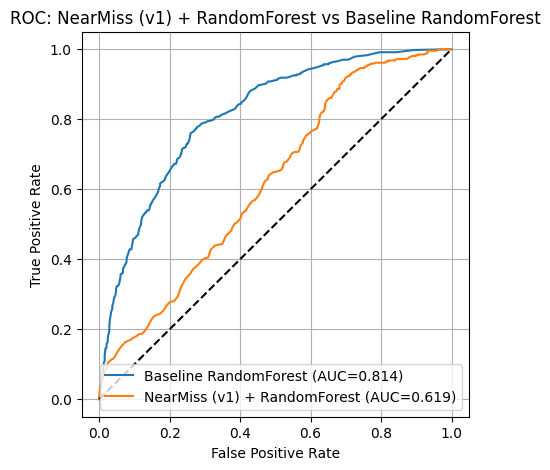

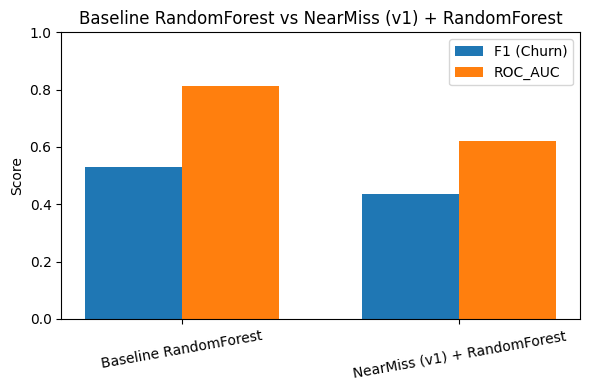

/usr/local/lib/python3.12/dist-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/_tags.py:354: FutureWarning: The NearMiss or classes from which it inherits use `_get_tags` and `_more_tags`. Please define the `__sklearn_tags__` method, or inherit from `sklearn.base.BaseEstimator` and/or other appropriate mixins such as `sklearn.base.TransformerMixin`, `sklearn.base.ClassifierMixin`, `sklearn.base.RegressorMixin`, and `sklearn.base.OutlierMixin`. From scikit-learn 1.7, not defining `__sklearn_tags__` will raise an error.
  warnings.warn(



===== NearMiss (v1) + SVM =====
              precision    recall  f1-score   support

    No Churn       0.87      0.41      0.56      1291
       Churn       0.34      0.83      0.48       467

    accuracy                           0.52      1758
   macro avg       0.60      0.62      0.52      1758
weighted avg       0.73      0.52      0.54      1758

NearMiss (v1) + SVM F1 (Churn): 0.4808
NearMiss (v1) + SVM ROC_AUC   : 0.6409


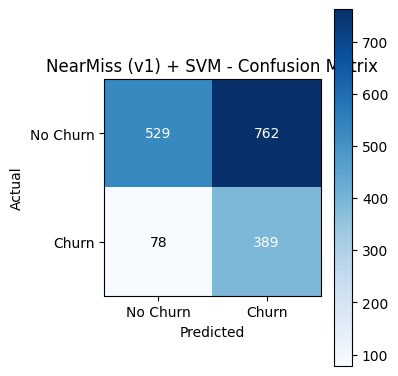

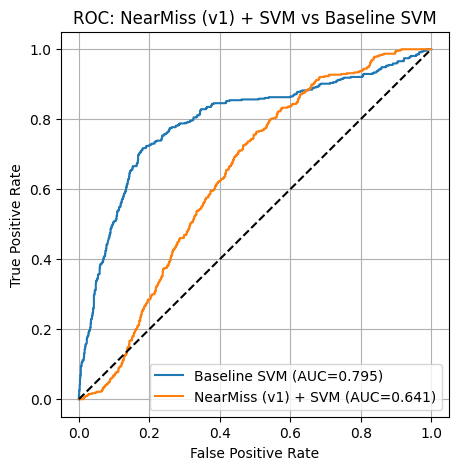

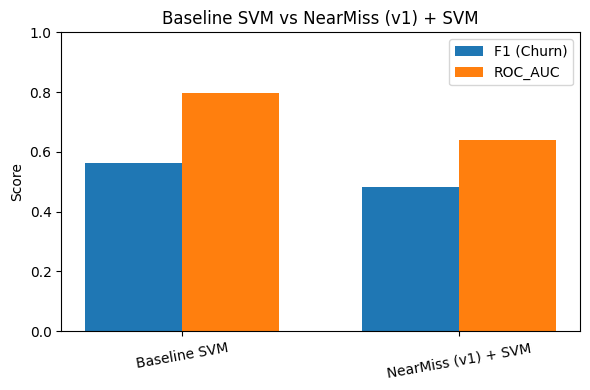

In [ ]:
# ===== NearMiss (v1) + 4 Models =====
nearmiss_logreg_results = compare_with_baseline(
    sampler_name="NearMiss (v1)",
    sampler=NearMiss(version=1),
    model_name="LogReg"
)

nearmiss_dt_results = compare_with_baseline(
    sampler_name="NearMiss (v1)",
    sampler=NearMiss(version=1),
    model_name="DecisionTree"
)

nearmiss_rf_results = compare_with_baseline(
    sampler_name="NearMiss (v1)",
    sampler=NearMiss(version=1),
    model_name="RandomForest"
)

nearmiss_svm_results = compare_with_baseline(
    sampler_name="NearMiss (v1)",
    sampler=NearMiss(version=1),
    model_name="SVM"
)


/usr/local/lib/python3.12/dist-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/_tags.py:354: FutureWarning: The InstanceHardnessThreshold or classes from which it inherits use `_get_tags` and `_more_tags`. Please define the `__sklearn_tags__` method, or inherit from `sklearn.base.BaseEstimator` and/or other appropriate mixins such as `sklearn.base.TransformerMixin`, `sklearn.base.ClassifierMixin`, `sklearn.base.RegressorMixin`, and `sklearn.base.OutlierMixin`. From scikit-learn 1.7, not defining `__sklearn_tags__` will raise an error.
  warnings.warn(



===== InstanceHardnessThreshold + LogReg =====
              precision    recall  f1-score   support

    No Churn       0.95      0.53      0.68      1291
       Churn       0.41      0.92      0.57       467

    accuracy                           0.63      1758
   macro avg       0.68      0.72      0.62      1758
weighted avg       0.81      0.63      0.65      1758

InstanceHardnessThreshold + LogReg F1 (Churn): 0.5693
InstanceHardnessThreshold + LogReg ROC_AUC   : 0.8314


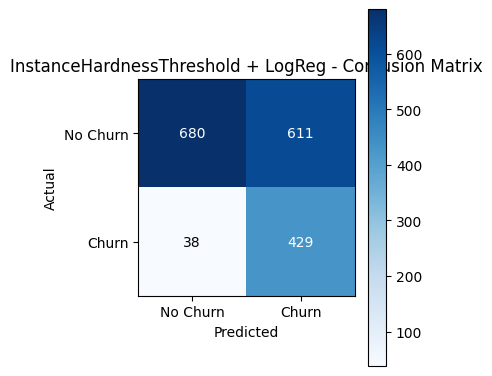

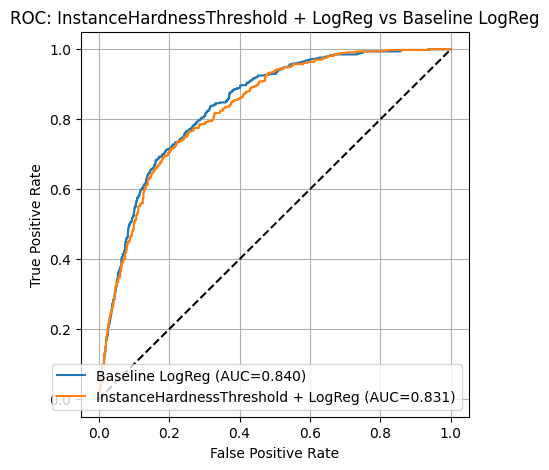

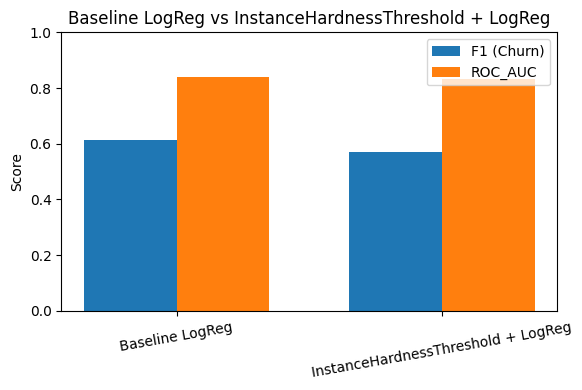

/usr/local/lib/python3.12/dist-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/_tags.py:354: FutureWarning: The InstanceHardnessThreshold or classes from which it inherits use `_get_tags` and `_more_tags`. Please define the `__sklearn_tags__` method, or inherit from `sklearn.base.BaseEstimator` and/or other appropriate mixins such as `sklearn.base.TransformerMixin`, `sklearn.base.ClassifierMixin`, `sklearn.base.RegressorMixin`, and `sklearn.base.OutlierMixin`. From scikit-learn 1.7, not defining `__sklearn_tags__` will raise an error.
  warnings.warn(



===== InstanceHardnessThreshold + DecisionTree =====
              precision    recall  f1-score   support

    No Churn       0.94      0.53      0.68      1291
       Churn       0.41      0.90      0.56       467

    accuracy                           0.63      1758
   macro avg       0.67      0.72      0.62      1758
weighted avg       0.80      0.63      0.65      1758

InstanceHardnessThreshold + DecisionTree F1 (Churn): 0.5634
InstanceHardnessThreshold + DecisionTree ROC_AUC   : 0.7165


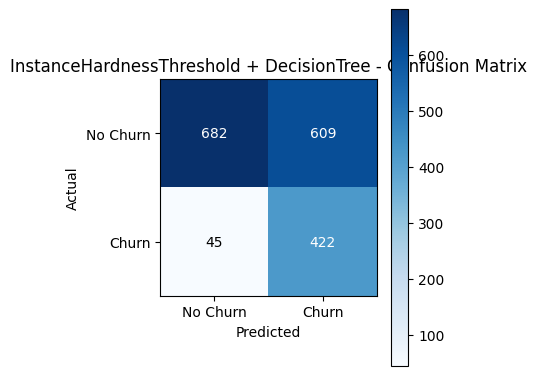

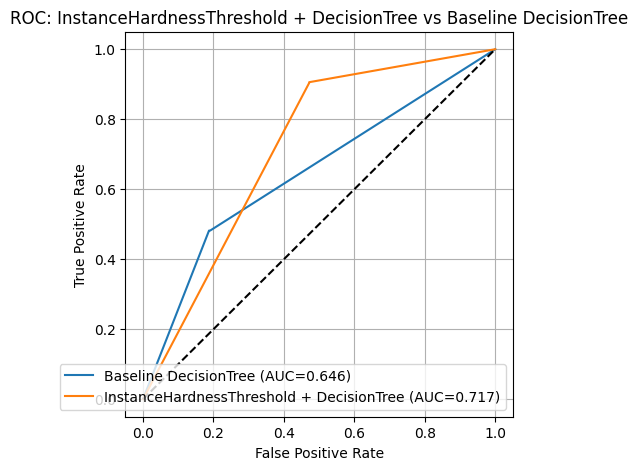

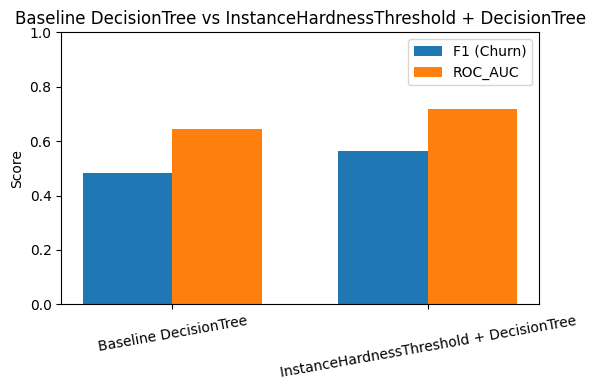

/usr/local/lib/python3.12/dist-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/_tags.py:354: FutureWarning: The InstanceHardnessThreshold or classes from which it inherits use `_get_tags` and `_more_tags`. Please define the `__sklearn_tags__` method, or inherit from `sklearn.base.BaseEstimator` and/or other appropriate mixins such as `sklearn.base.TransformerMixin`, `sklearn.base.ClassifierMixin`, `sklearn.base.RegressorMixin`, and `sklearn.base.OutlierMixin`. From scikit-learn 1.7, not defining `__sklearn_tags__` will raise an error.
  warnings.warn(



===== InstanceHardnessThreshold + RandomForest =====
              precision    recall  f1-score   support

    No Churn       0.95      0.52      0.67      1291
       Churn       0.41      0.92      0.57       467

    accuracy                           0.63      1758
   macro avg       0.68      0.72      0.62      1758
weighted avg       0.81      0.63      0.64      1758

InstanceHardnessThreshold + RandomForest F1 (Churn): 0.5675
InstanceHardnessThreshold + RandomForest ROC_AUC   : 0.8211


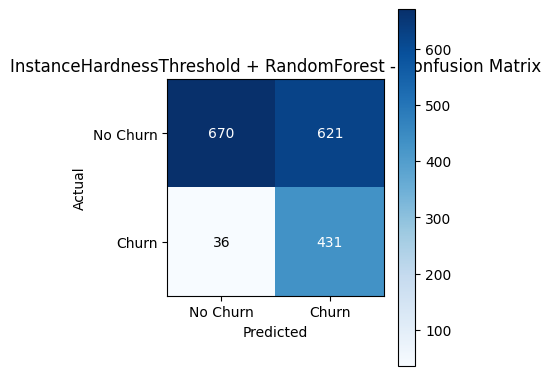

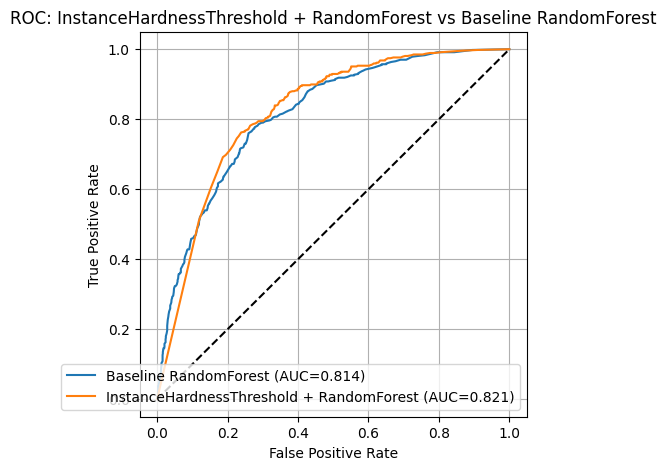

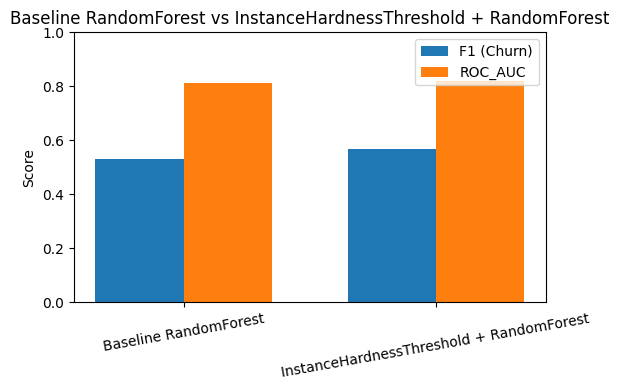

/usr/local/lib/python3.12/dist-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/_tags.py:354: FutureWarning: The InstanceHardnessThreshold or classes from which it inherits use `_get_tags` and `_more_tags`. Please define the `__sklearn_tags__` method, or inherit from `sklearn.base.BaseEstimator` and/or other appropriate mixins such as `sklearn.base.TransformerMixin`, `sklearn.base.ClassifierMixin`, `sklearn.base.RegressorMixin`, and `sklearn.base.OutlierMixin`. From scikit-learn 1.7, not defining `__sklearn_tags__` will raise an error.
  warnings.warn(



===== InstanceHardnessThreshold + SVM =====
              precision    recall  f1-score   support

    No Churn       0.93      0.55      0.69      1291
       Churn       0.42      0.89      0.57       467

    accuracy                           0.64      1758
   macro avg       0.67      0.72      0.63      1758
weighted avg       0.79      0.64      0.66      1758

InstanceHardnessThreshold + SVM F1 (Churn): 0.5666
InstanceHardnessThreshold + SVM ROC_AUC   : 0.8227


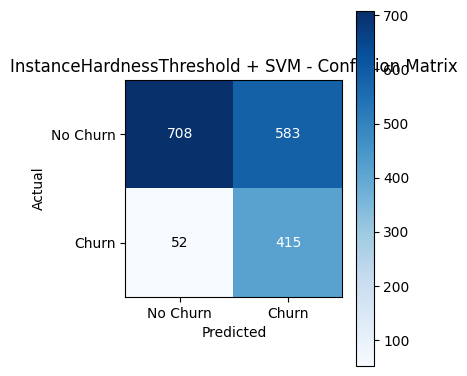

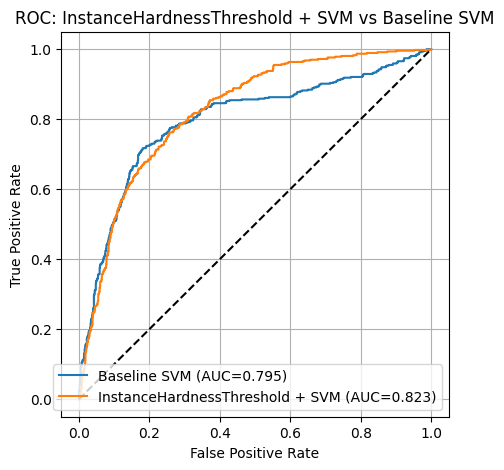

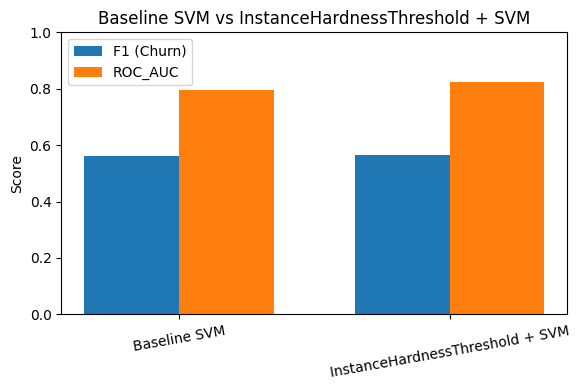

In [ ]:
# ===== Instance Hardness Threshold + 4 Models =====
iht_logreg_results = compare_with_baseline(
    sampler_name="InstanceHardnessThreshold",
    sampler=InstanceHardnessThreshold(random_state=42),
    model_name="LogReg"
)

iht_dt_results = compare_with_baseline(
    sampler_name="InstanceHardnessThreshold",
    sampler=InstanceHardnessThreshold(random_state=42),
    model_name="DecisionTree"
)

iht_rf_results = compare_with_baseline(
    sampler_name="InstanceHardnessThreshold",
    sampler=InstanceHardnessThreshold(random_state=42),
    model_name="RandomForest"
)

iht_svm_results = compare_with_baseline(
    sampler_name="InstanceHardnessThreshold",
    sampler=InstanceHardnessThreshold(random_state=42),
    model_name="SVM"
)



===== VAE-SMOTE + LogReg =====
              precision    recall  f1-score   support

    No Churn       0.85      0.89      0.87      1291
       Churn       0.66      0.57      0.61       467

    accuracy                           0.81      1758
   macro avg       0.75      0.73      0.74      1758
weighted avg       0.80      0.81      0.80      1758

VAE-SMOTE + LogReg F1 (Churn): 0.6119
VAE-SMOTE + LogReg ROC_AUC   : 0.8402


/usr/local/lib/python3.12/dist-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/_tags.py:354: FutureWarning: The VAESMOTE or classes from which it inherits use `_get_tags` and `_more_tags`. Please define the `__sklearn_tags__` method, or inherit from `sklearn.base.BaseEstimator` and/or other appropriate mixins such as `sklearn.base.TransformerMixin`, `sklearn.base.ClassifierMixin`, `sklearn.base.RegressorMixin`, and `sklearn.base.OutlierMixin`. From scikit-learn 1.7, not defining `__sklearn_tags__` will raise an error.
  warnings.warn(


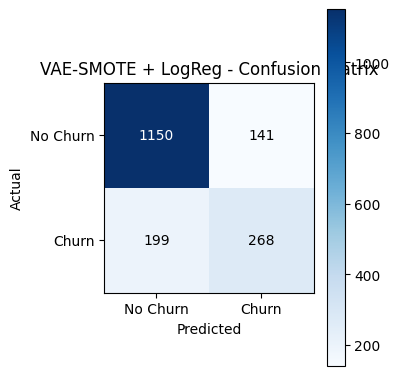

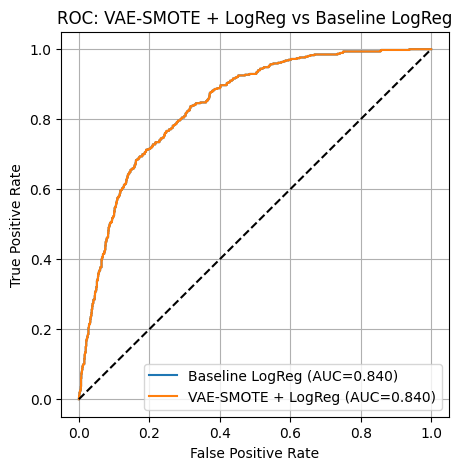

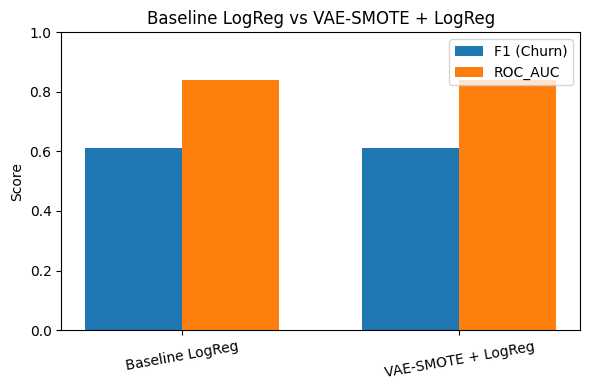


===== VAE-SMOTE + DecisionTree =====
              precision    recall  f1-score   support

    No Churn       0.81      0.81      0.81      1291
       Churn       0.48      0.48      0.48       467

    accuracy                           0.72      1758
   macro avg       0.65      0.65      0.65      1758
weighted avg       0.72      0.72      0.72      1758

VAE-SMOTE + DecisionTree F1 (Churn): 0.4813
VAE-SMOTE + DecisionTree ROC_AUC   : 0.6464


/usr/local/lib/python3.12/dist-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/_tags.py:354: FutureWarning: The VAESMOTE or classes from which it inherits use `_get_tags` and `_more_tags`. Please define the `__sklearn_tags__` method, or inherit from `sklearn.base.BaseEstimator` and/or other appropriate mixins such as `sklearn.base.TransformerMixin`, `sklearn.base.ClassifierMixin`, `sklearn.base.RegressorMixin`, and `sklearn.base.OutlierMixin`. From scikit-learn 1.7, not defining `__sklearn_tags__` will raise an error.
  warnings.warn(


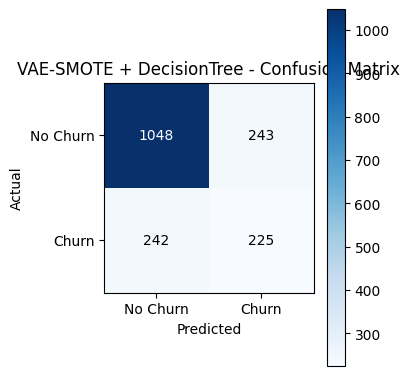

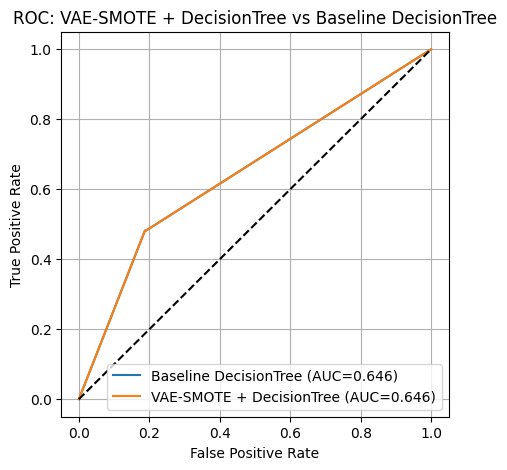

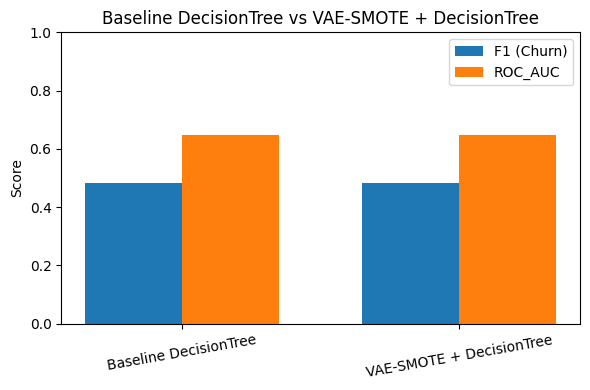

/usr/local/lib/python3.12/dist-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/_tags.py:354: FutureWarning: The VAESMOTE or classes from which it inherits use `_get_tags` and `_more_tags`. Please define the `__sklearn_tags__` method, or inherit from `sklearn.base.BaseEstimator` and/or other appropriate mixins such as `sklearn.base.TransformerMixin`, `sklearn.base.ClassifierMixin`, `sklearn.base.RegressorMixin`, and `sklearn.base.OutlierMixin`. From scikit-learn 1.7, not defining `__sklearn_tags__` will raise an error.
  warnings.warn(



===== VAE-SMOTE + RandomForest =====
              precision    recall  f1-score   support

    No Churn       0.82      0.89      0.85      1291
       Churn       0.61      0.47      0.53       467

    accuracy                           0.78      1758
   macro avg       0.71      0.68      0.69      1758
weighted avg       0.77      0.78      0.77      1758

VAE-SMOTE + RandomForest F1 (Churn): 0.5290
VAE-SMOTE + RandomForest ROC_AUC   : 0.8136


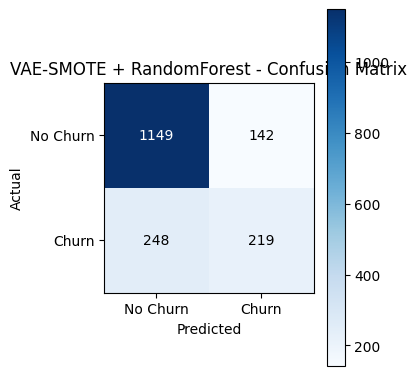

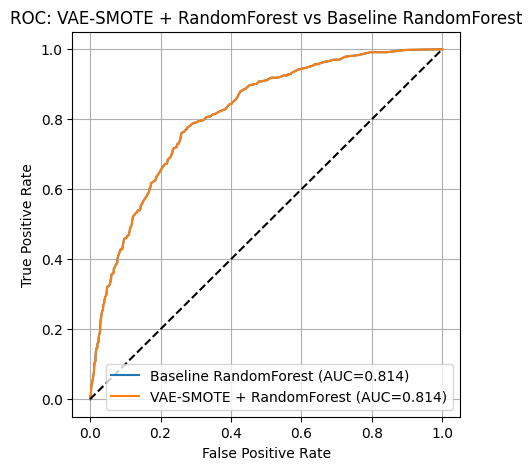

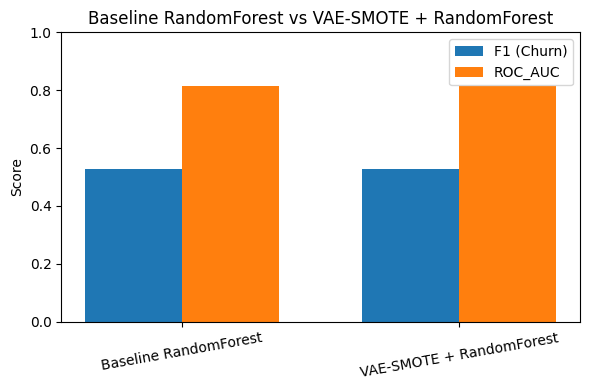

/usr/local/lib/python3.12/dist-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/_tags.py:354: FutureWarning: The VAESMOTE or classes from which it inherits use `_get_tags` and `_more_tags`. Please define the `__sklearn_tags__` method, or inherit from `sklearn.base.BaseEstimator` and/or other appropriate mixins such as `sklearn.base.TransformerMixin`, `sklearn.base.ClassifierMixin`, `sklearn.base.RegressorMixin`, and `sklearn.base.OutlierMixin`. From scikit-learn 1.7, not defining `__sklearn_tags__` will raise an error.
  warnings.warn(



===== VAE-SMOTE + SVM =====
              precision    recall  f1-score   support

    No Churn       0.83      0.91      0.87      1291
       Churn       0.66      0.49      0.56       467

    accuracy                           0.80      1758
   macro avg       0.74      0.70      0.71      1758
weighted avg       0.79      0.80      0.79      1758

VAE-SMOTE + SVM F1 (Churn): 0.5620
VAE-SMOTE + SVM ROC_AUC   : 0.7955


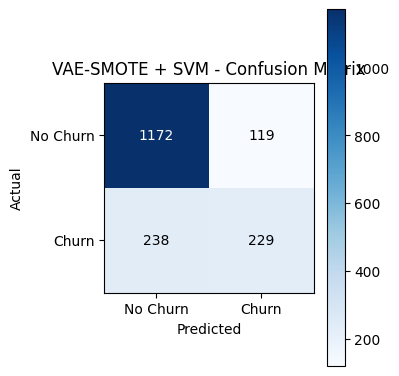

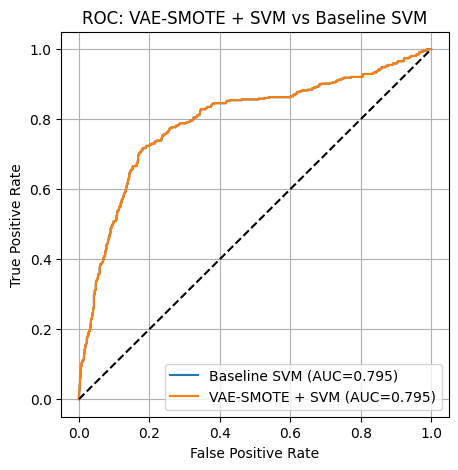

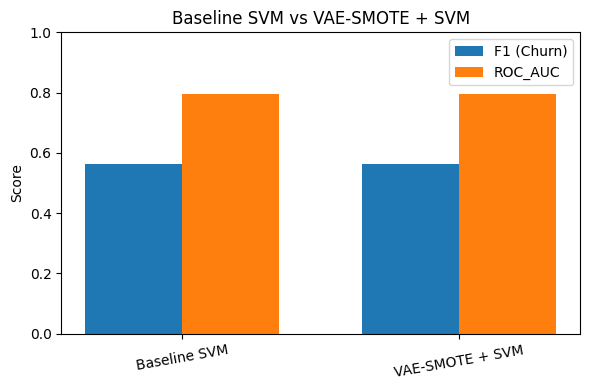

In [ ]:
# ===== VAE-SMOTE + 4 Models =====
vaesmote_logreg_results = compare_with_baseline(
    sampler_name="VAE-SMOTE",
    sampler=VAESMOTE(random_state=42),
    model_name="LogReg"
)

vaesmote_dt_results = compare_with_baseline(
    sampler_name="VAE-SMOTE",
    sampler=VAESMOTE(random_state=42),
    model_name="DecisionTree"
)

vaesmote_rf_results = compare_with_baseline(
    sampler_name="VAE-SMOTE",
    sampler=VAESMOTE(random_state=42),
    model_name="RandomForest"
)

vaesmote_svm_results = compare_with_baseline(
    sampler_name="VAE-SMOTE",
    sampler=VAESMOTE(random_state=42),
    model_name="SVM"
)



===== GAN-Oversampler + LogReg =====
              precision    recall  f1-score   support

    No Churn       0.85      0.89      0.87      1291
       Churn       0.66      0.57      0.61       467

    accuracy                           0.81      1758
   macro avg       0.75      0.73      0.74      1758
weighted avg       0.80      0.81      0.80      1758

GAN-Oversampler + LogReg F1 (Churn): 0.6119
GAN-Oversampler + LogReg ROC_AUC   : 0.8402


/usr/local/lib/python3.12/dist-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/_tags.py:354: FutureWarning: The GANOversampler or classes from which it inherits use `_get_tags` and `_more_tags`. Please define the `__sklearn_tags__` method, or inherit from `sklearn.base.BaseEstimator` and/or other appropriate mixins such as `sklearn.base.TransformerMixin`, `sklearn.base.ClassifierMixin`, `sklearn.base.RegressorMixin`, and `sklearn.base.OutlierMixin`. From scikit-learn 1.7, not defining `__sklearn_tags__` will raise an error.
  warnings.warn(


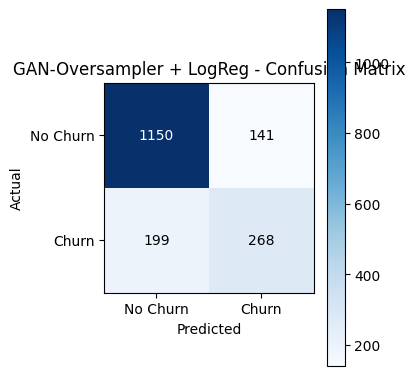

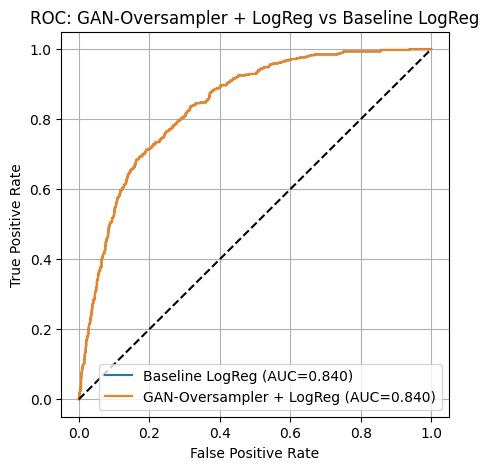

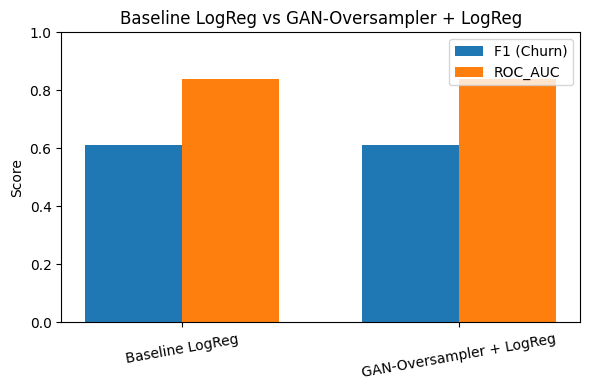


===== GAN-Oversampler + DecisionTree =====
              precision    recall  f1-score   support

    No Churn       0.81      0.81      0.81      1291
       Churn       0.48      0.48      0.48       467

    accuracy                           0.72      1758
   macro avg       0.65      0.65      0.65      1758
weighted avg       0.72      0.72      0.72      1758

GAN-Oversampler + DecisionTree F1 (Churn): 0.4813
GAN-Oversampler + DecisionTree ROC_AUC   : 0.6464


/usr/local/lib/python3.12/dist-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/_tags.py:354: FutureWarning: The GANOversampler or classes from which it inherits use `_get_tags` and `_more_tags`. Please define the `__sklearn_tags__` method, or inherit from `sklearn.base.BaseEstimator` and/or other appropriate mixins such as `sklearn.base.TransformerMixin`, `sklearn.base.ClassifierMixin`, `sklearn.base.RegressorMixin`, and `sklearn.base.OutlierMixin`. From scikit-learn 1.7, not defining `__sklearn_tags__` will raise an error.
  warnings.warn(


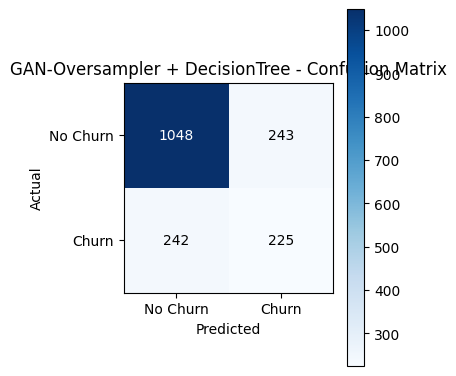

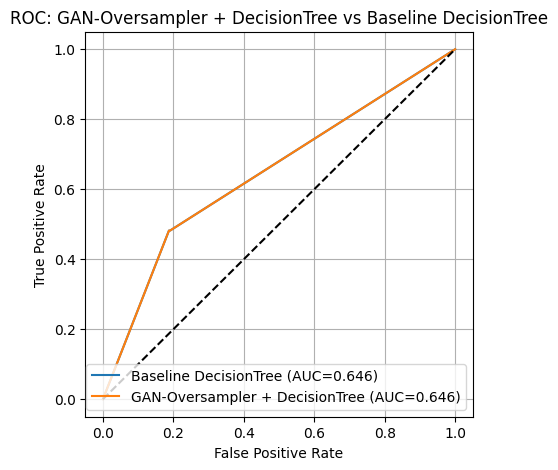

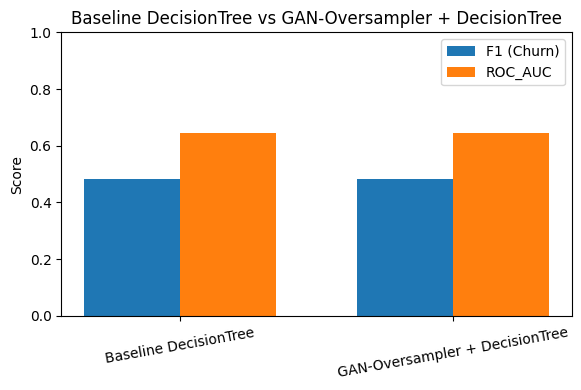

/usr/local/lib/python3.12/dist-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/_tags.py:354: FutureWarning: The GANOversampler or classes from which it inherits use `_get_tags` and `_more_tags`. Please define the `__sklearn_tags__` method, or inherit from `sklearn.base.BaseEstimator` and/or other appropriate mixins such as `sklearn.base.TransformerMixin`, `sklearn.base.ClassifierMixin`, `sklearn.base.RegressorMixin`, and `sklearn.base.OutlierMixin`. From scikit-learn 1.7, not defining `__sklearn_tags__` will raise an error.
  warnings.warn(



===== GAN-Oversampler + RandomForest =====
              precision    recall  f1-score   support

    No Churn       0.82      0.89      0.85      1291
       Churn       0.61      0.47      0.53       467

    accuracy                           0.78      1758
   macro avg       0.71      0.68      0.69      1758
weighted avg       0.77      0.78      0.77      1758

GAN-Oversampler + RandomForest F1 (Churn): 0.5290
GAN-Oversampler + RandomForest ROC_AUC   : 0.8136


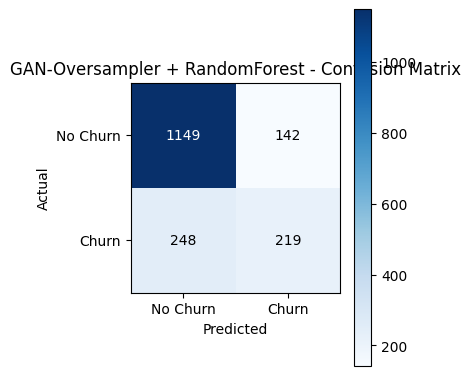

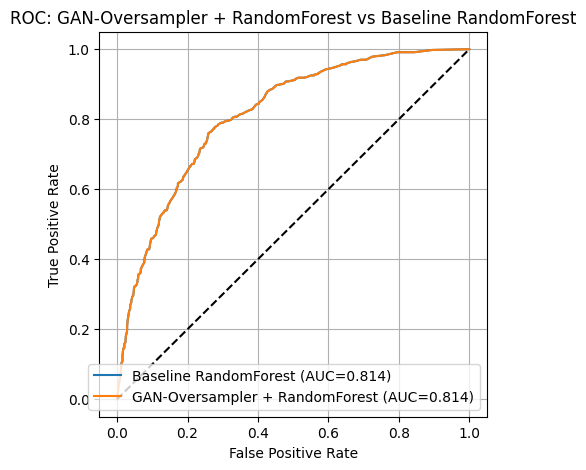

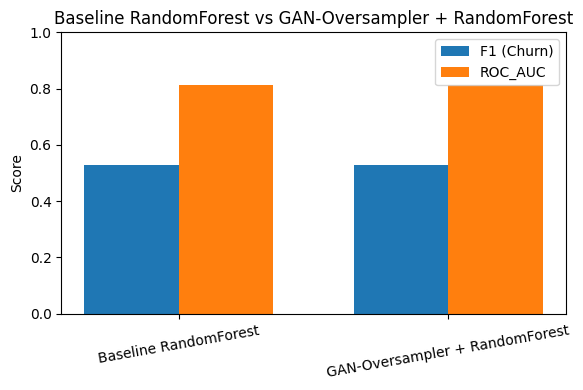

/usr/local/lib/python3.12/dist-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/_tags.py:354: FutureWarning: The GANOversampler or classes from which it inherits use `_get_tags` and `_more_tags`. Please define the `__sklearn_tags__` method, or inherit from `sklearn.base.BaseEstimator` and/or other appropriate mixins such as `sklearn.base.TransformerMixin`, `sklearn.base.ClassifierMixin`, `sklearn.base.RegressorMixin`, and `sklearn.base.OutlierMixin`. From scikit-learn 1.7, not defining `__sklearn_tags__` will raise an error.
  warnings.warn(



===== GAN-Oversampler + SVM =====
              precision    recall  f1-score   support

    No Churn       0.83      0.91      0.87      1291
       Churn       0.66      0.49      0.56       467

    accuracy                           0.80      1758
   macro avg       0.74      0.70      0.71      1758
weighted avg       0.79      0.80      0.79      1758

GAN-Oversampler + SVM F1 (Churn): 0.5620
GAN-Oversampler + SVM ROC_AUC   : 0.7955


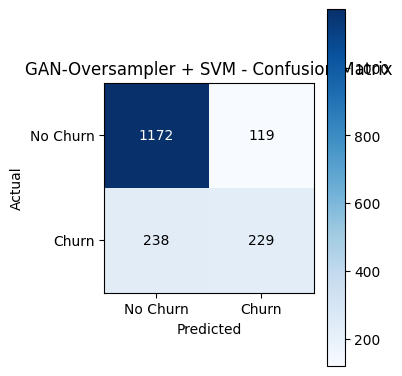

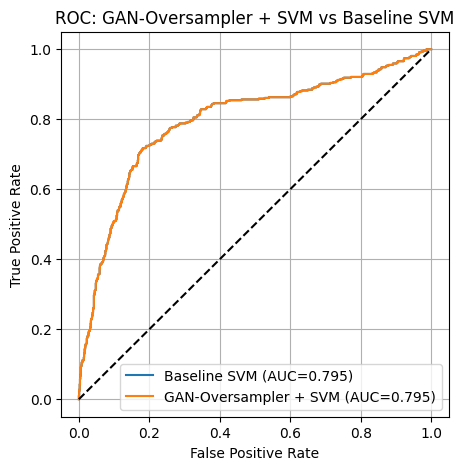

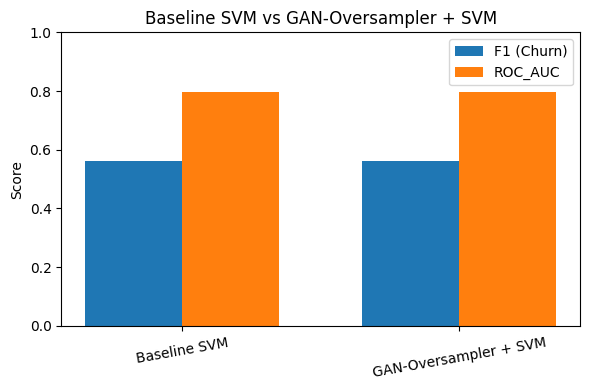

In [ ]:
# ===== GAN-Oversampler + 4 Models =====
gan_logreg_results = compare_with_baseline(
    sampler_name="GAN-Oversampler",
    sampler=GANOversampler(random_state=42),
    model_name="LogReg"
)

gan_dt_results = compare_with_baseline(
    sampler_name="GAN-Oversampler",
    sampler=GANOversampler(random_state=42),
    model_name="DecisionTree"
)

gan_rf_results = compare_with_baseline(
    sampler_name="GAN-Oversampler",
    sampler=GANOversampler(random_state=42),
    model_name="RandomForest"
)

gan_svm_results = compare_with_baseline(
    sampler_name="GAN-Oversampler",
    sampler=GANOversampler(random_state=42),
    model_name="SVM"
)


In [ ]:


# ============================
# Collect all *_results dicts
# ============================
results_records = []

for name, val in list(globals().items()):
    if (
        isinstance(name, str)
        and name.endswith("_results")
        and isinstance(val, dict)
        and {"sampler", "model", "f1", "auc"}.issubset(val.keys())
    ):
        results_records.append(val)

results_df = pd.DataFrame(results_records)

# ============================
# Add baselines into the table
# ============================
baseline_rows = []
for model_name, info in baseline_results.items():
    baseline_rows.append({
        "sampler": "Baseline (No Sampling)",
        "model": model_name,
        "f1": info["f1"],
        "auc": info["auc"],
    })

baseline_df = pd.DataFrame(baseline_rows)

# Combine
all_results_df = pd.concat([baseline_df, results_df], ignore_index=True)

# Nicely sorted: by model, then F1, then AUC
all_results_df = all_results_df.sort_values(
    by=["model", "f1", "auc"],
    ascending=[True, False, False]
).reset_index(drop=True)

all_results_df


,sampler,model,f1,auc
0,SMOTE-ENN,DecisionTree,0.585167,0.729062
1,InstanceHardnessThreshold,DecisionTree,0.563418,0.716522
2,SMOTE-Tomek,DecisionTree,0.529293,0.679089
3,SMOTE,DecisionTree,0.524851,0.675980
4,Cluster-SMOTE,DecisionTree,0.516598,0.670210
5,ADASYN,DecisionTree,0.506639,0.663767
6,Baseline (No Sampling),DecisionTree,0.481283,0.646371
7,MajorityDensity,DecisionTree,0.481283,0.646371
8,VAE-SMOTE,DecisionTree,0.481283,0.646371
9,GAN-Oversampler,DecisionTree,0.481283,0.646371


In [ ]:
# F1-score pivot table (sampler vs model)
f1_pivot = all_results_df.pivot_table(
    index="sampler", columns="model", values="f1"
)

# AUC pivot table
auc_pivot = all_results_df.pivot_table(
    index="sampler", columns="model", values="auc"
)

f1_pivot, auc_pivot


(model                      DecisionTree    LogReg  RandomForest       SVM
 sampler                                                                  
 ADASYN                         0.506639  0.611894      0.551948  0.609362
 Baseline (No Sampling)         0.481283  0.611872      0.528986  0.561963
 Cluster-SMOTE                  0.516598  0.644135      0.555809  0.588754
 GAN-Oversampler                0.481283  0.611872      0.528986  0.561963
 InstanceHardnessThreshold      0.563418  0.569343      0.567479  0.566553
 MajorityDensity                0.481283  0.611872      0.528986  0.561963
 NearMiss (v1)                  0.405202  0.555636      0.434159  0.480841
 SMOTE                          0.524851  0.616915      0.544858  0.618246
 SMOTE-ENN                      0.585167  0.585579      0.608765  0.589763
 SMOTE-Tomek                    0.529293  0.616404      0.561213  0.617569
 VAE-SMOTE                      0.481283  0.611872      0.528986  0.561963,
 model                  

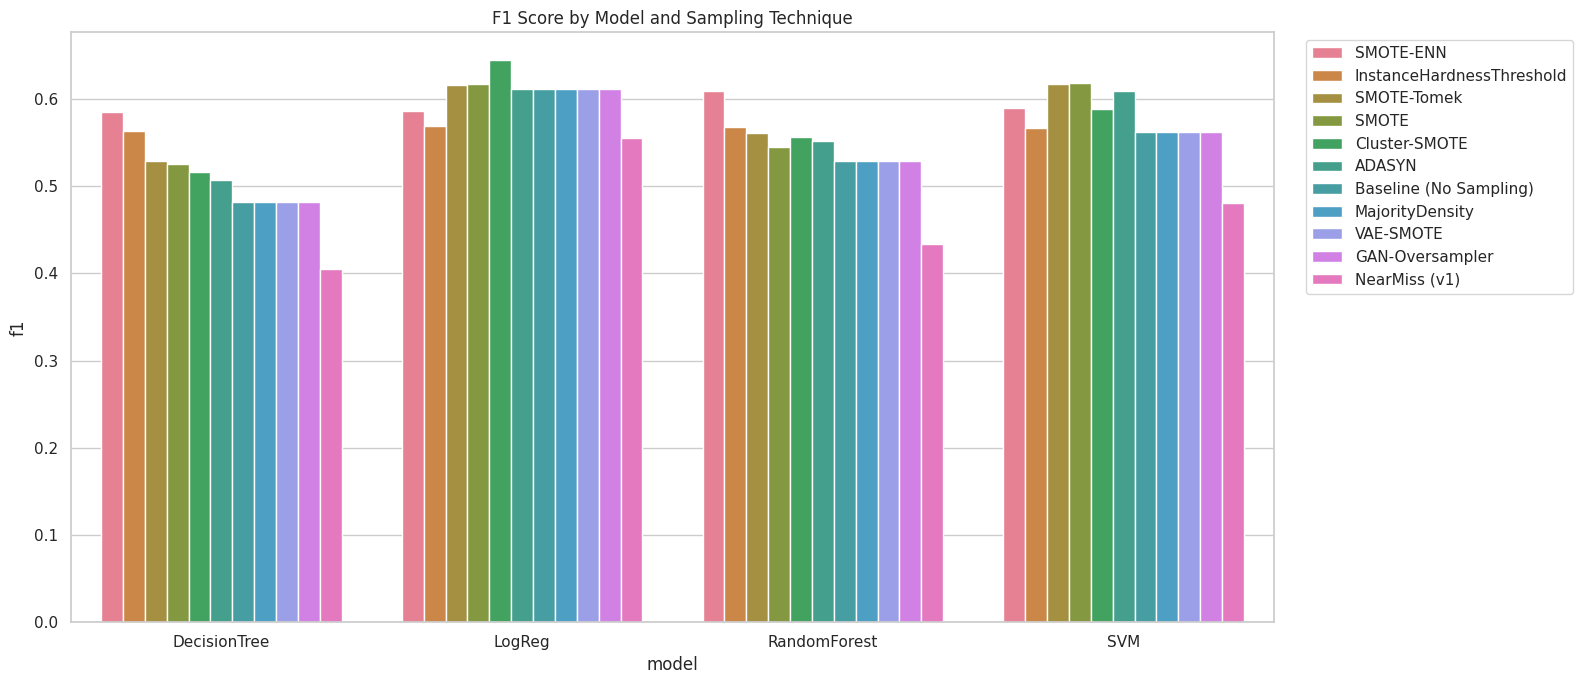

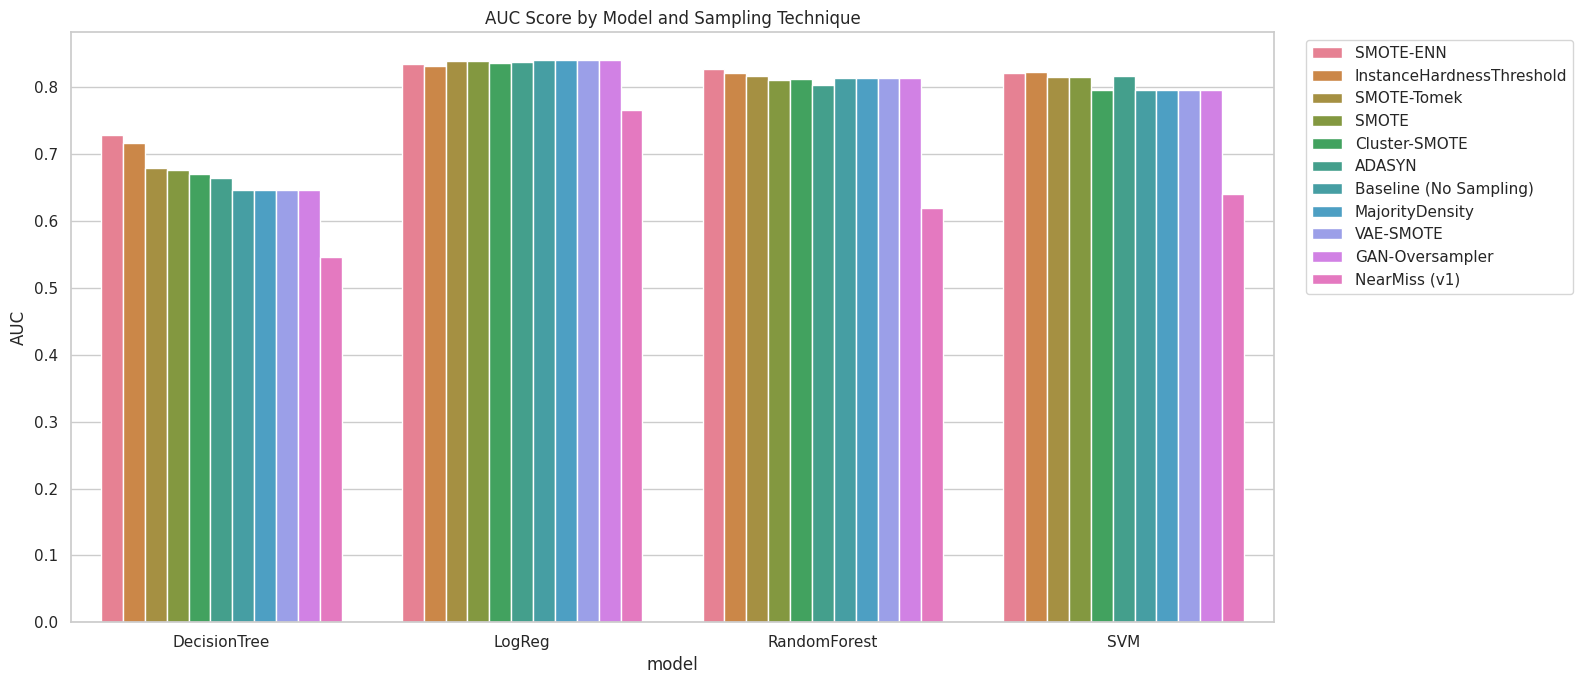

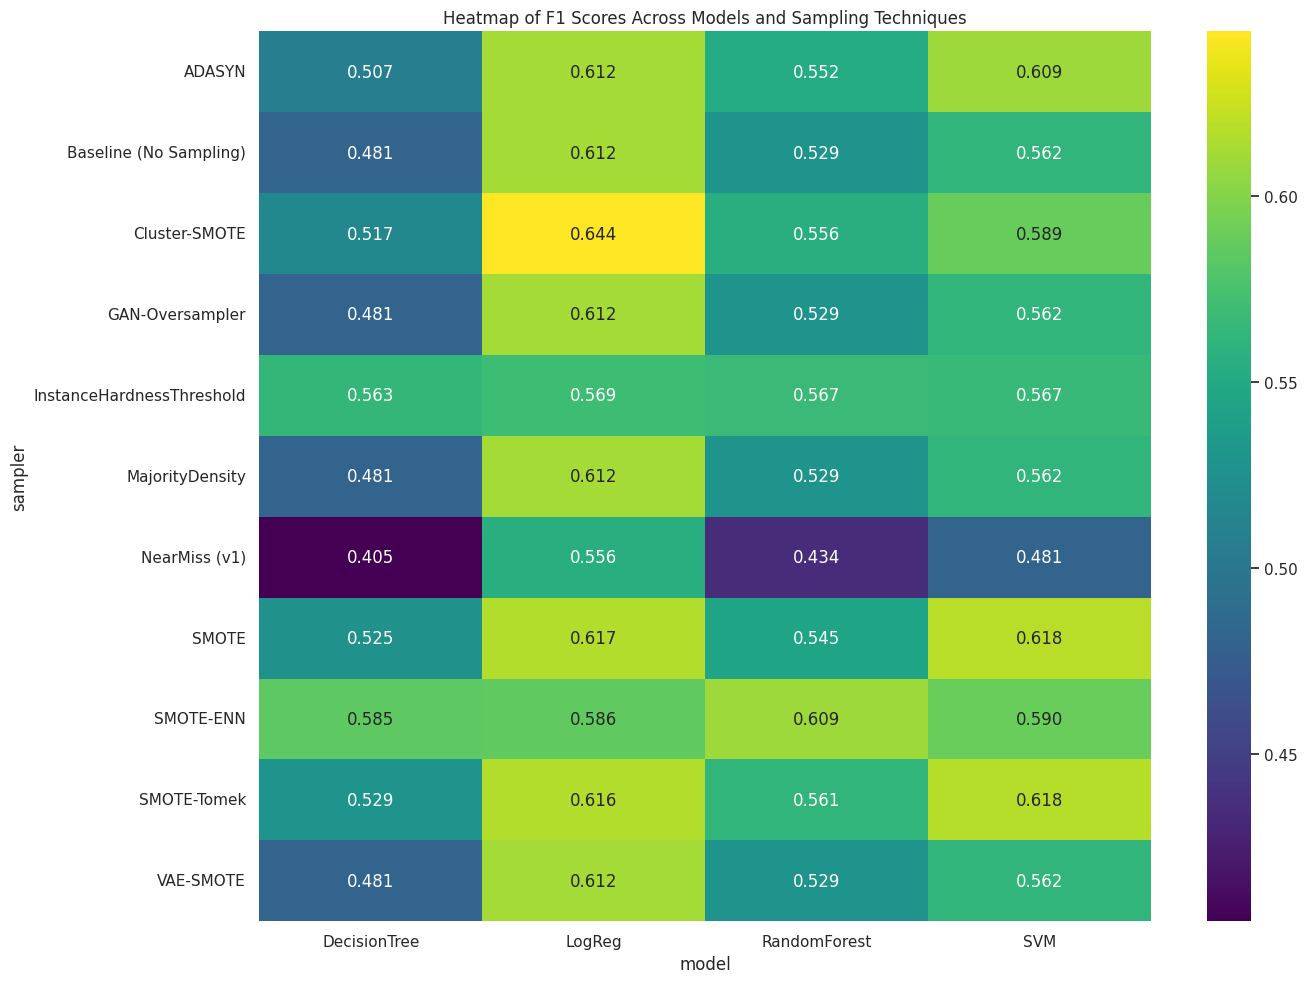

/tmp/ipython-input-1054314514.py:56: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=subset, x="f1", y="sampler", palette="mako")


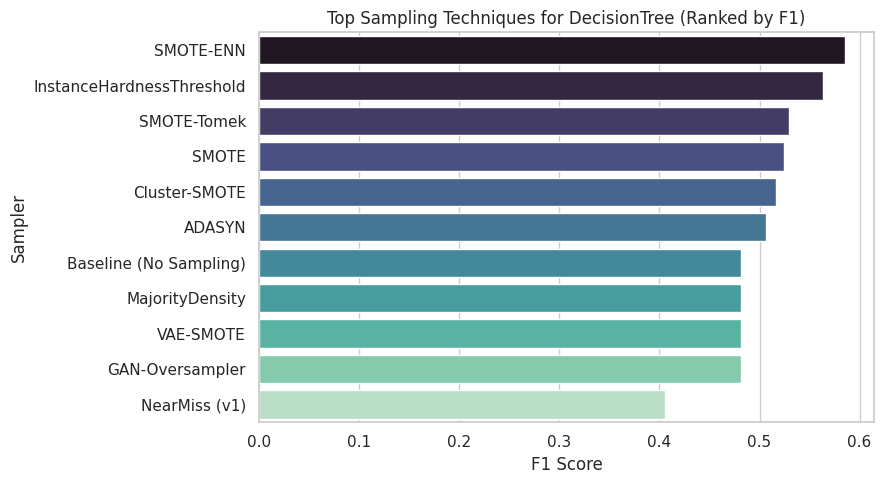

/tmp/ipython-input-1054314514.py:56: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=subset, x="f1", y="sampler", palette="mako")


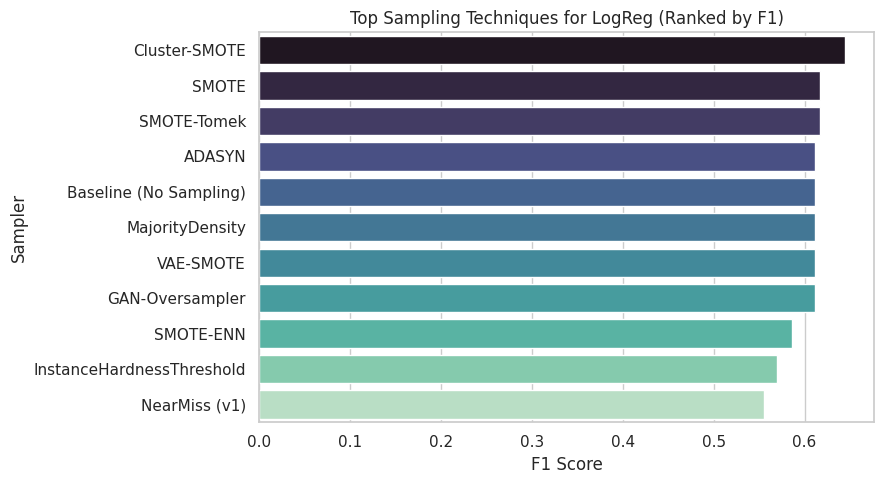

/tmp/ipython-input-1054314514.py:56: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=subset, x="f1", y="sampler", palette="mako")


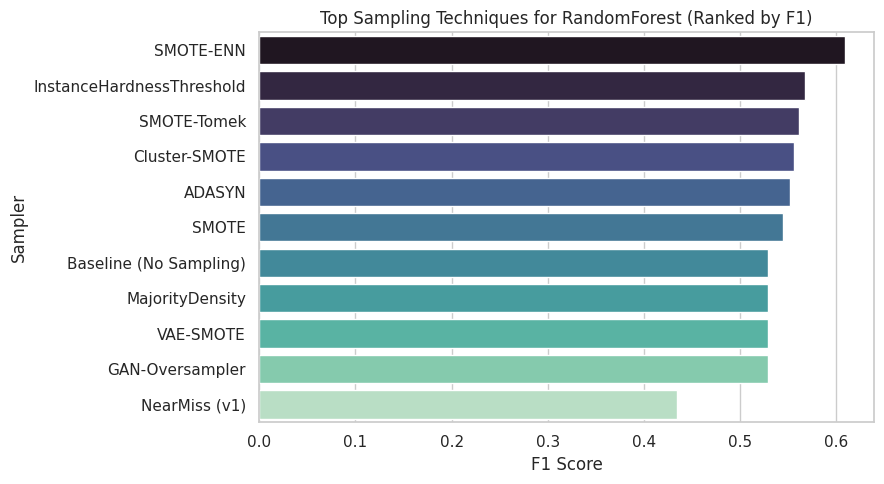

/tmp/ipython-input-1054314514.py:56: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=subset, x="f1", y="sampler", palette="mako")


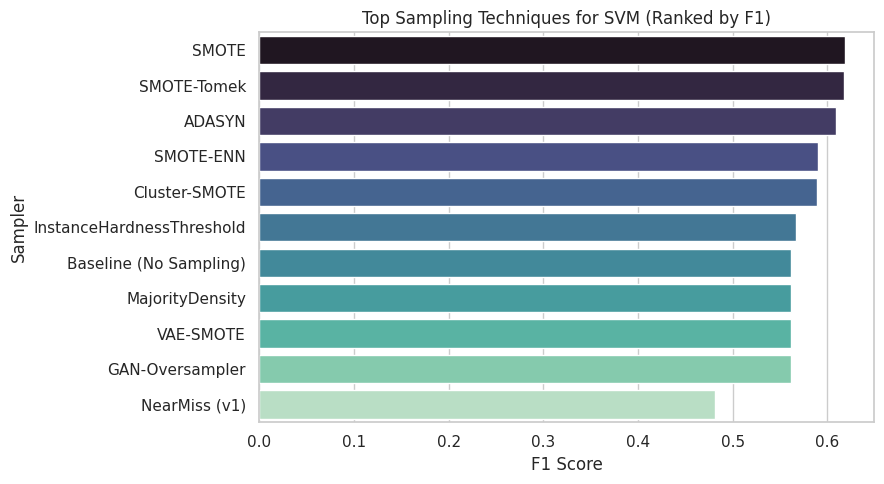

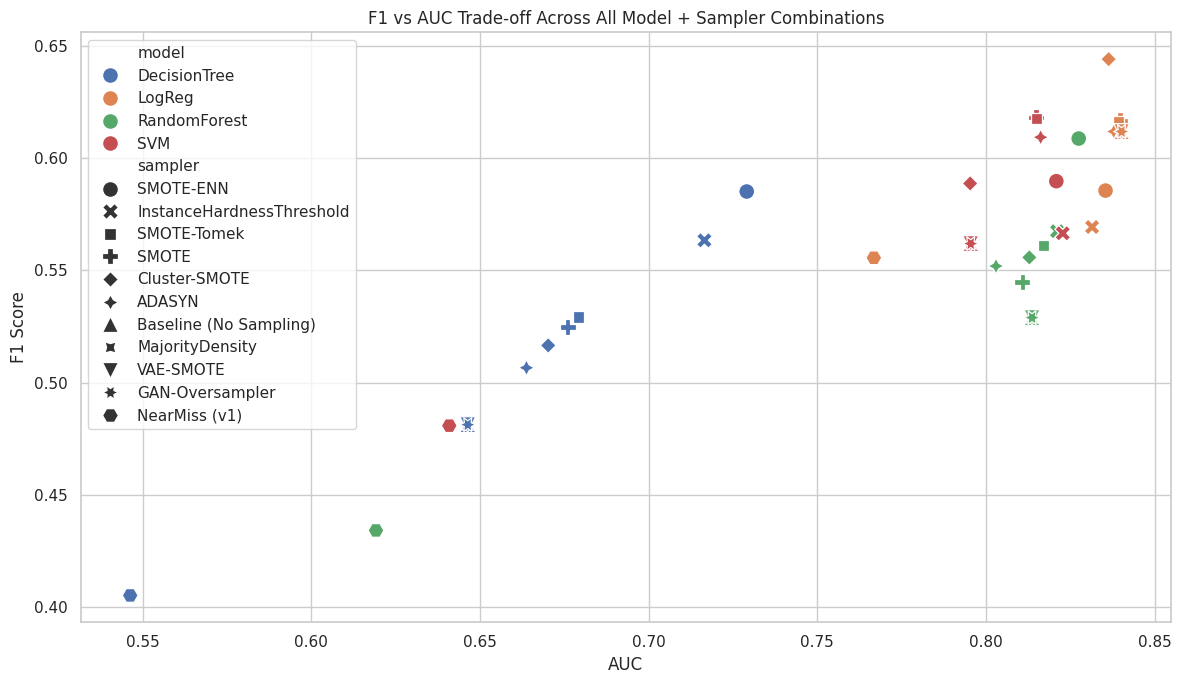

In [ ]:
import seaborn as sns

sns.set(style="whitegrid")

# ==========================================================
# 1) GROUPED BAR CHART — F1 by Model + Sampler
# ==========================================================
plt.figure(figsize=(16, 7))
sns.barplot(data=all_results_df, x="model", y="f1", hue="sampler", errorbar=None)
plt.title("F1 Score by Model and Sampling Technique")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

# ==========================================================
# GROUPED BAR CHART — AUC by Model + Sampler
# ==========================================================
plt.figure(figsize=(16, 7))
sns.barplot(
    data=all_results_df,
    x="model",
    y="auc",
    hue="sampler",
    errorbar=None
)

plt.title("AUC Score by Model and Sampling Technique")
plt.ylabel("AUC")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()


# ==========================================================
# 2) HEATMAP — Sampler × Model (F1)
# ==========================================================
pivot_f1 = all_results_df.pivot_table(values="f1", index="sampler", columns="model")

plt.figure(figsize=(14, 10))
sns.heatmap(pivot_f1, annot=True, cmap="viridis", fmt=".3f")
plt.title("Heatmap of F1 Scores Across Models and Sampling Techniques")
plt.tight_layout()
plt.show()

# ==========================================================
# 3) MODEL-WISE TOP SAMPLERS — RANKING
# ==========================================================
models = all_results_df["model"].unique()

for m in models:
    subset = all_results_df[all_results_df["model"] == m].sort_values("f1", ascending=False)

    plt.figure(figsize=(9, 5))
    sns.barplot(data=subset, x="f1", y="sampler", palette="mako")
    plt.title(f"Top Sampling Techniques for {m} (Ranked by F1)")
    plt.xlabel("F1 Score")
    plt.ylabel("Sampler")
    plt.tight_layout()
    plt.show()

# ==========================================================
# 4) SCATTER PLOT — F1 vs AUC Trade-off
# ==========================================================
plt.figure(figsize=(12, 7))
sns.scatterplot(
    data=all_results_df,
    x="auc",
    y="f1",
    hue="model",
    style="sampler",
    s=130
)

plt.title("F1 vs AUC Trade-off Across All Model + Sampler Combinations")
plt.xlabel("AUC")
plt.ylabel("F1 Score")
plt.tight_layout()
plt.show()


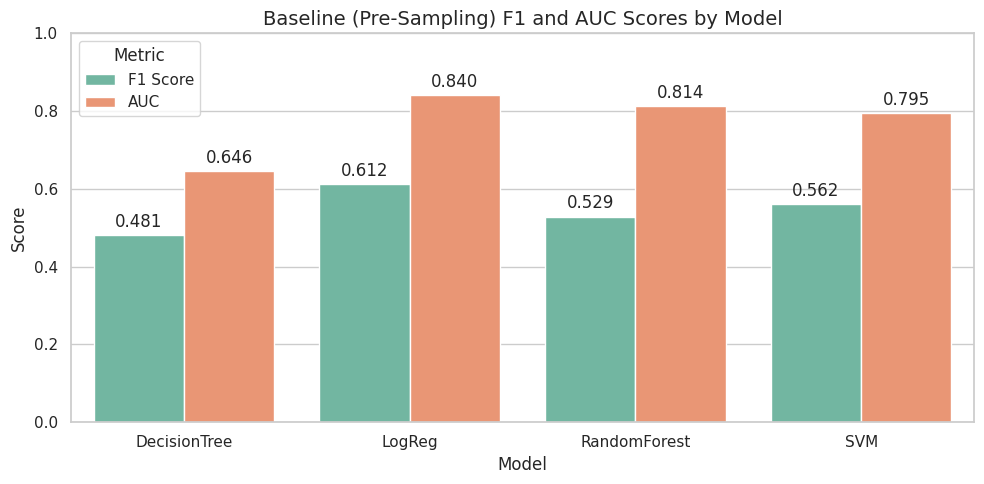

In [ ]:


sns.set(style="whitegrid")

# ===================================
# Extract only baseline rows
# ===================================
baseline_df = all_results_df[all_results_df["sampler"] == "Baseline (No Sampling)"]

# Ensure proper model order
model_order = ["DecisionTree", "LogReg", "RandomForest", "SVM"]
baseline_df = baseline_df.set_index("model").loc[model_order].reset_index()

# Melt the DF to plot F1 + AUC together
baseline_melted = baseline_df.melt(id_vars="model", value_vars=["f1", "auc"],
                                   var_name="Metric", value_name="Score")

baseline_melted["Metric"] = baseline_melted["Metric"].map({
    "f1": "F1 Score",
    "auc": "AUC"
})

# ===================================
# Plot the combined bar chart
# ===================================
plt.figure(figsize=(10,5))
ax = sns.barplot(data=baseline_melted, x="model", y="Score", hue="Metric", palette="Set2")

plt.title("Baseline (Pre-Sampling) F1 and AUC Scores by Model", fontsize=14)
plt.xlabel("Model")
plt.ylabel("Score")


# ===================================
# FIXED: Label each bar accurately by reading its coordinates
# ===================================
for container in ax.containers:
    ax.bar_label(container, fmt="%.3f", padding=3)

plt.ylim(0, 1)
plt.tight_layout()
plt.show()
